<div class="alert alert-block alert-info">
Singapore Management University<br>
<i>CS105 Statistical Thinking for Data Science</i>
</div>

# Lab 3: Modeling

In many of the data science projects, we are dealing with either a _regression_ problem or a _classification_ problem.
- In a _regression_ problem, the dependent varaible is numerical. For example, in Secion A of this lab, our objective is to predict the price of a house based on selected dependent variables. We will demonstrate the pipeline of modeling a regression problem in this lab.
- In a _classification_ problem, the dependent variable is categorical. For example, in the titanic dataset (Lab 1), the objective is to predict if a passenger falls belongs to the 'survived' category or the 'perished' category. Details of classification will be demonstrated in Section B of this lab.

Nonetheless, regardless of whether it is a _regression_ or _classification_ problem, we can generally apply the following workflow

- Problem formulation
- Dataset Exploration
- Data Preprocessing
- Feature Selection
- Model Building
- Model Evaluation

In this lab we will illustrate how to apply the above workflow. In [Section A](#section_a), we will work on a regression problem and in [Section B](#section_b) we will work on a classification problem

<a id="section_a"></a>
## Section A: Linear Regression

>#### Table of Contents
>
>- Introduction
>- Dataset Exploration
>- Data Preprocessing
>- Feature Selection
>    - Categorical Variables
>    - Numerical Variables
>- Model Building
>- Model Evaluation
>- Conclusion
>- References

## 1 Introduction

In many of the data science projects, we are dealing with either a _regression_ problem or a _classification_ problem.
- In a _regression_ problem, the dependent varaible is numerical. For example, in this lab, our objective is to predict the price of a house based on selected dependent variables. We will demonstrate the pipeline of modeling a regression problem in this lab.
- In a _classification_ problem, the dependent variable is categorical. For example, in the titanic dataset (Lab 2), the objective is to predict if a passenger falls belongs to the 'survived' category or the 'perished' category. Details of classification will be demonstrated in Lab 5.

Nonetheless, regardless of whether it is a _regression_ or _classification_ problem, we can generally apply the following workflow

- Problem formulation
- Dataset Exploration
- Data Preprocessing
- Feature Selection
- Model Building
- Model Evaluation

## 2 Problem Formulation

Home ownership is one of the major life decisions for many people.  Consequently it is important to understand what drives house prices and develop a sound method to be able to predict the fair value of a house.  In this lab we will be tackling the topic of housing prices.  Specifically we use the Ames Housing Dataset as the basis to perform exploratory data analysis and subsequently build a linear regression model.

The Ames Housing Dataset is a rich dataset describing the sale of individual residential property in Ames, Iowa, in the United States from the year 2006 to 2010.  It is a structured tabular dataset with close to 3000 rows and 80 columns.  The variable we want to predict is the housing price, and there are quite some explanatory variables including material, quality, square footage etc.

In the following sections, we begin with quick exploration of the dataset followed by cleansing and pre-processing the data.  We then perform exploratory data analysis (EDA) to understand the distribution of variables and their correlations.  During the process of EDA we would select and engineer appropriate features that are important in the prediction of housing price.  We finally build two multiple linear regression models on train dataset and evaluate the models on a test dataset.

## 3 Dataset Exploration

In [74]:
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [75]:
data = pd.read_excel("AmesHousing.xls")

In [76]:
data.sample(5, random_state=42)

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
1357,1358,903427090,70,RM,NaN,5100,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,OldTown,Norm,Norm,1Fam,2Story,8,7,1925,1996,Hip,CompShg,Stucco,Wd Shng,None,0.0,TA,Gd,PConc,TA,TA,No,Unf,0.0,Unf,0.0,588.0,588.0,GasA,Fa,Y,SBrkr,833,833,0,1666,0.0,0.0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1925.0,Unf,1.0,228.0,TA,TA,Y,192,63,0,0,0,0,NaN,MnPrv,NaN,0,6,2008,WD,Normal,161000
2367,2368,527450460,160,RM,21.0,1890,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,BrDale,Norm,Norm,Twnhs,2Story,6,7,1972,1972,Gable,CompShg,HdBoard,HdBoard,BrkFace,380.0,TA,TA,CBlock,TA,TA,No,ALQ,282.0,Unf,0.0,212.0,494.0,GasA,Ex,Y,SBrkr,494,536,0,1030,0.0,0.0,1,1,3,1,TA,6,Typ,0,NaN,Detchd,1973.0,Unf,1.0,264.0,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,7,2006,WD,Normal,116000
2822,2823,908128100,60,RL,62.0,7162,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Edwards,Norm,Norm,1Fam,2Story,7,5,2003,2004,Hip,CompShg,HdBoard,Stucco,BrkFace,190.0,Gd,TA,PConc,Gd,TA,No,Unf,0.0,Unf,0.0,796.0,796.0,GasA,Ex,Y,SBrkr,806,918,0,1724,0.0,0.0,2,1,3,1,Gd,8,Typ,1,Gd,BuiltIn,2003.0,Fin,2.0,616.0,TA,TA,Y,168,57,0,0,0,0,NaN,NaN,NaN,0,5,2006,WD,Normal,196500
2126,2127,907135180,20,RL,60.0,8070,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,1Story,4,5,1994,1995,Gable,CompShg,VinylSd,VinylSd,None,0.0,TA,TA,PConc,Gd,TA,No,GLQ,588.0,Unf,0.0,402.0,990.0,GasA,Ex,Y,SBrkr,990,0,0,990,1.0,0.0,1,0,3,1,TA,5,Typ,0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal,123600
1544,1545,910200080,30,RM,50.0,7000,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,IDOTRR,Norm,Norm,1Fam,1Story,6,8,1926,1998,Gable,CompShg,VinylSd,VinylSd,None,0.0,TA,Gd,BrkTil,TA,TA,No,Rec,299.0,GLQ,40.0,555.0,894.0,GasA,TA,Y,SBrkr,919,0,0,919,1.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Detchd,1926.0,Unf,1.0,195.0,TA,TA,P,0,0,116,0,0,0,NaN,MnPrv,NaN,0,7,2008,WD,Normal,126000


A quick peek with the following observations
- `Order` is an index which we can ignore
- there are some missing values that need to be dealt with
- there are both categorical and numerical variables

In [77]:
n_rows, n_cols = data.shape
n_rows, n_cols

(2930, 82)

There are a total of 2930 observations with 82 columns, i.e., 1 target variable and 81 independent variables.

In [78]:
# Get a list of numerical, categorical features

datatypes = data.dtypes
print(datatypes)

categorical_features = datatypes[datatypes=="object"].index
numerical_features = datatypes[datatypes!="object"].index

Order               int64
PID                 int64
MS SubClass         int64
MS Zoning          object
Lot Frontage      float64
                   ...   
Mo Sold             int64
Yr Sold             int64
Sale Type          object
Sale Condition     object
SalePrice           int64
Length: 82, dtype: object


In [79]:
print(f"# categorical features: {len(categorical_features)}")
print(f"# numerical features: {len(numerical_features)}")

# categorical features: 43
# numerical features: 39


## 4 Data Preprocessing

We now look into issue of missing data.

In [80]:
# calculate percentage of non-NaN data

missing_percent = 1 - data.count() / n_rows


# filter for columns with non-zero count of NaN data

missing_percent[missing_percent > 0.0]
print(f"# features with missing data : {len(missing_percent[missing_percent>0.0])}")

# features with missing data : 27


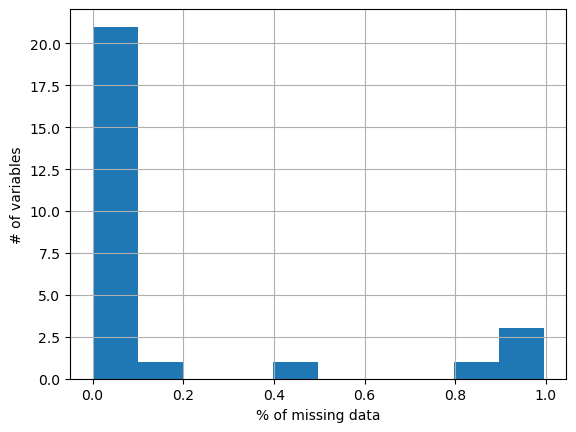

In [81]:
missing_percent[missing_percent>0.].hist()
plt.xlabel("% of missing data")
plt.ylabel("# of variables")
plt.show()

We will drop columns if missing data is more than 20%.  For those with less than 10% missing data, we would impute with mode or mean.

In [82]:
# get columns with > 20% missing data, and drop in-place

threshold = 0.20
cols_to_drop = missing_percent[missing_percent>threshold].index
print(f"Columns to drop: {cols_to_drop}")
data.drop(columns=cols_to_drop, inplace=True)

Columns to drop: Index(['Alley', 'Fireplace Qu', 'Pool QC', 'Fence', 'Misc Feature'], dtype='object')


In [83]:
# get categorical variables with < 10% missing data and impute with mode

threshold = 0.10
cols_to_impute = missing_percent[(missing_percent<threshold)&(missing_percent>0.0)].index
cols_to_impute_mode = list(set(cols_to_impute) & set(categorical_features))
print(f"Categorical columns to impute with mode: {cols_to_impute_mode}\n")

for col in cols_to_impute_mode:
    data[col].fillna(data[col].mode().iloc[0], inplace=True)

# confirm no missing values

print(data[cols_to_impute_mode].count())

Categorical columns to impute with mode: ['Mas Vnr Type', 'Garage Type', 'Garage Finish', 'Bsmt Cond', 'Bsmt Qual', 'BsmtFin Type 2', 'Garage Cond', 'Garage Qual', 'Bsmt Exposure', 'Electrical', 'BsmtFin Type 1']

Mas Vnr Type      2930
Garage Type       2930
Garage Finish     2930
Bsmt Cond         2930
Bsmt Qual         2930
BsmtFin Type 2    2930
Garage Cond       2930
Garage Qual       2930
Bsmt Exposure     2930
Electrical        2930
BsmtFin Type 1    2930
dtype: int64


In [84]:
# get numerical variables with < 10% missing data and impute with mean

threshold = 0.10
cols_to_impute = missing_percent[(missing_percent<threshold)&(missing_percent>0.0)].index
cols_to_impute_mean = list(set(cols_to_impute) & set(numerical_features))
print(f"Numerical columns to impute with mode: {cols_to_impute_mean}\n")

for col in cols_to_impute_mean:
    data[col].fillna(data[col].mean(), inplace=True)

# confirm no missing data

print(data[cols_to_impute_mean].count())

Numerical columns to impute with mode: ['BsmtFin SF 2', 'Bsmt Half Bath', 'Total Bsmt SF', 'Garage Cars', 'Bsmt Unf SF', 'BsmtFin SF 1', 'Garage Area', 'Bsmt Full Bath', 'Mas Vnr Area', 'Garage Yr Blt']

BsmtFin SF 2      2930
Bsmt Half Bath    2930
Total Bsmt SF     2930
Garage Cars       2930
Bsmt Unf SF       2930
BsmtFin SF 1      2930
Garage Area       2930
Bsmt Full Bath    2930
Mas Vnr Area      2930
Garage Yr Blt     2930
dtype: int64


In [85]:
missing_percent[(missing_percent>.10) & (missing_percent<.2)]

Lot Frontage    0.167235
dtype: float64

Finally we need to handle the remaining missing column `Lot Frontage` which has 16% of missing data.  We plot a histogram of the variable and found that it is unimodal.  Hence imputing it with mean would be a reasonable choice.

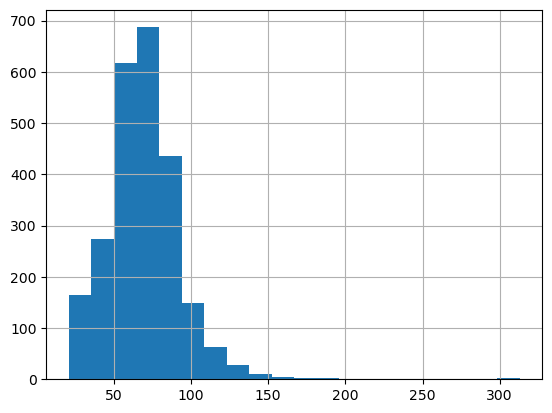

In [86]:
data["Lot Frontage"].hist(bins=20)
plt.show()

In [87]:
data["Lot Frontage"].fillna(data["Lot Frontage"].mean(), inplace=True)

# confirm no missing data

missing_data = 1. - data.count() / n_rows
missing_data[missing_data>0.]

Series([], dtype: float64)

## 5 Feature Selection

In this section we will perform EDA to understand the data.  The main outcome of this exercise is to help us do feature selection and feature engineering.  In other words, we want to design a set of attributes which could be used as our independent variables to predict the `SalePrice` in our model later.

In [88]:
datatypes = data.dtypes
categorical_features = datatypes[datatypes=="object"].index
numerical_features = datatypes[datatypes!="object"].index

### 5.1 Categorical Variables

First, we investigate the distribution of each variable by plotting barplots as below

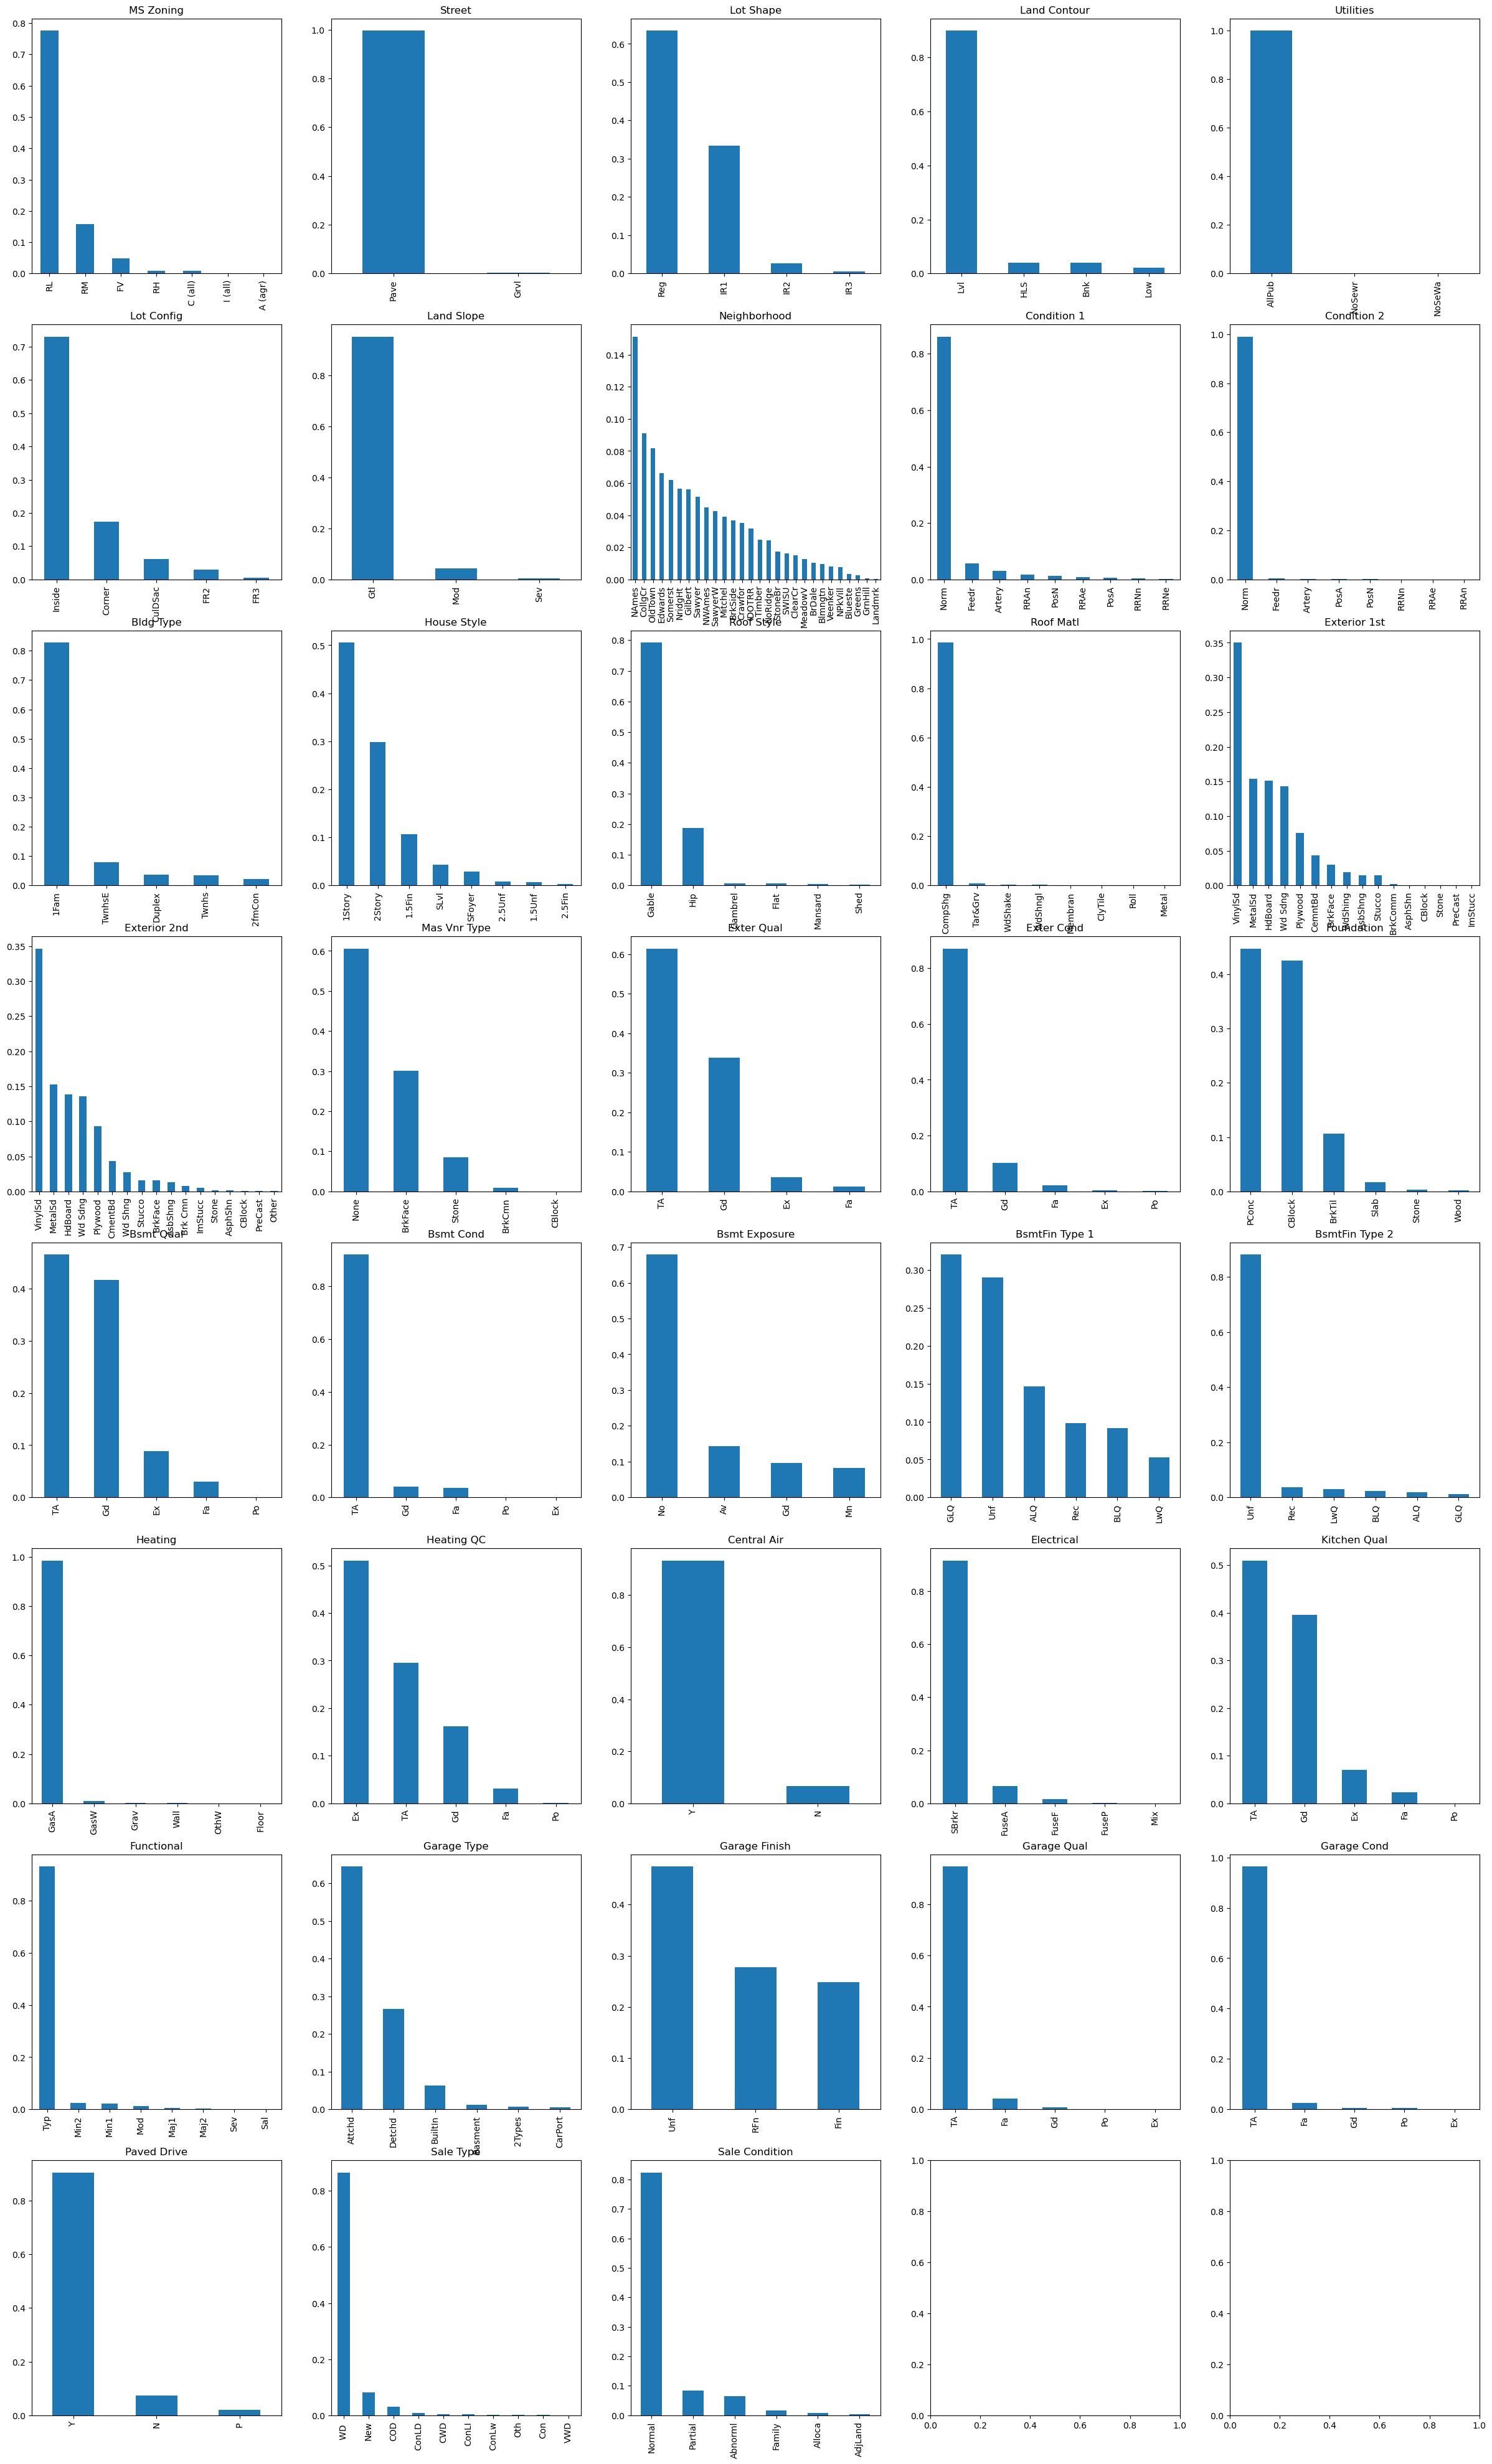

In [89]:
n = len(categorical_features)

r, c = 8,5
fig, ax = plt.subplots(r, c, figsize=(30,50))

for i in range(n):
    feature = categorical_features[i]
    ax = plt.subplot(r,c,i+1)
    ax.set_title(feature)
    data[feature].value_counts(normalize=True).plot(kind='bar')

plt.show()

We observed that many of the variables have a dominant value.  The lack of variation in these variables means that these variables are likey to have little explanatory power on the variation in `SalePrice`.  Hence we will not select these features.  The criteria we use is that we will not select features where its mode has a frequency of more than 50%. 

In [90]:
# get 'important' categorical features i.e. those with mode having freq < 50%

categorical_important = []

for feature in categorical_features:
    highest = data[feature].value_counts(normalize=True)[0]
    if highest<0.5:
        categorical_important.append(feature)

print(f"Variables with mode contributing <50% are : {categorical_important}")

Variables with mode contributing <50% are : ['Neighborhood', 'Exterior 1st', 'Exterior 2nd', 'Foundation', 'Bsmt Qual', 'BsmtFin Type 1', 'Garage Finish']


Based on the criteria we would keep these seven categorical variables.  We next look into how the `SalePrice` is related to these variables.  To do that we plot a grouped boxplot and see the distribution of `SalePrice` across different categories for a given variable. 

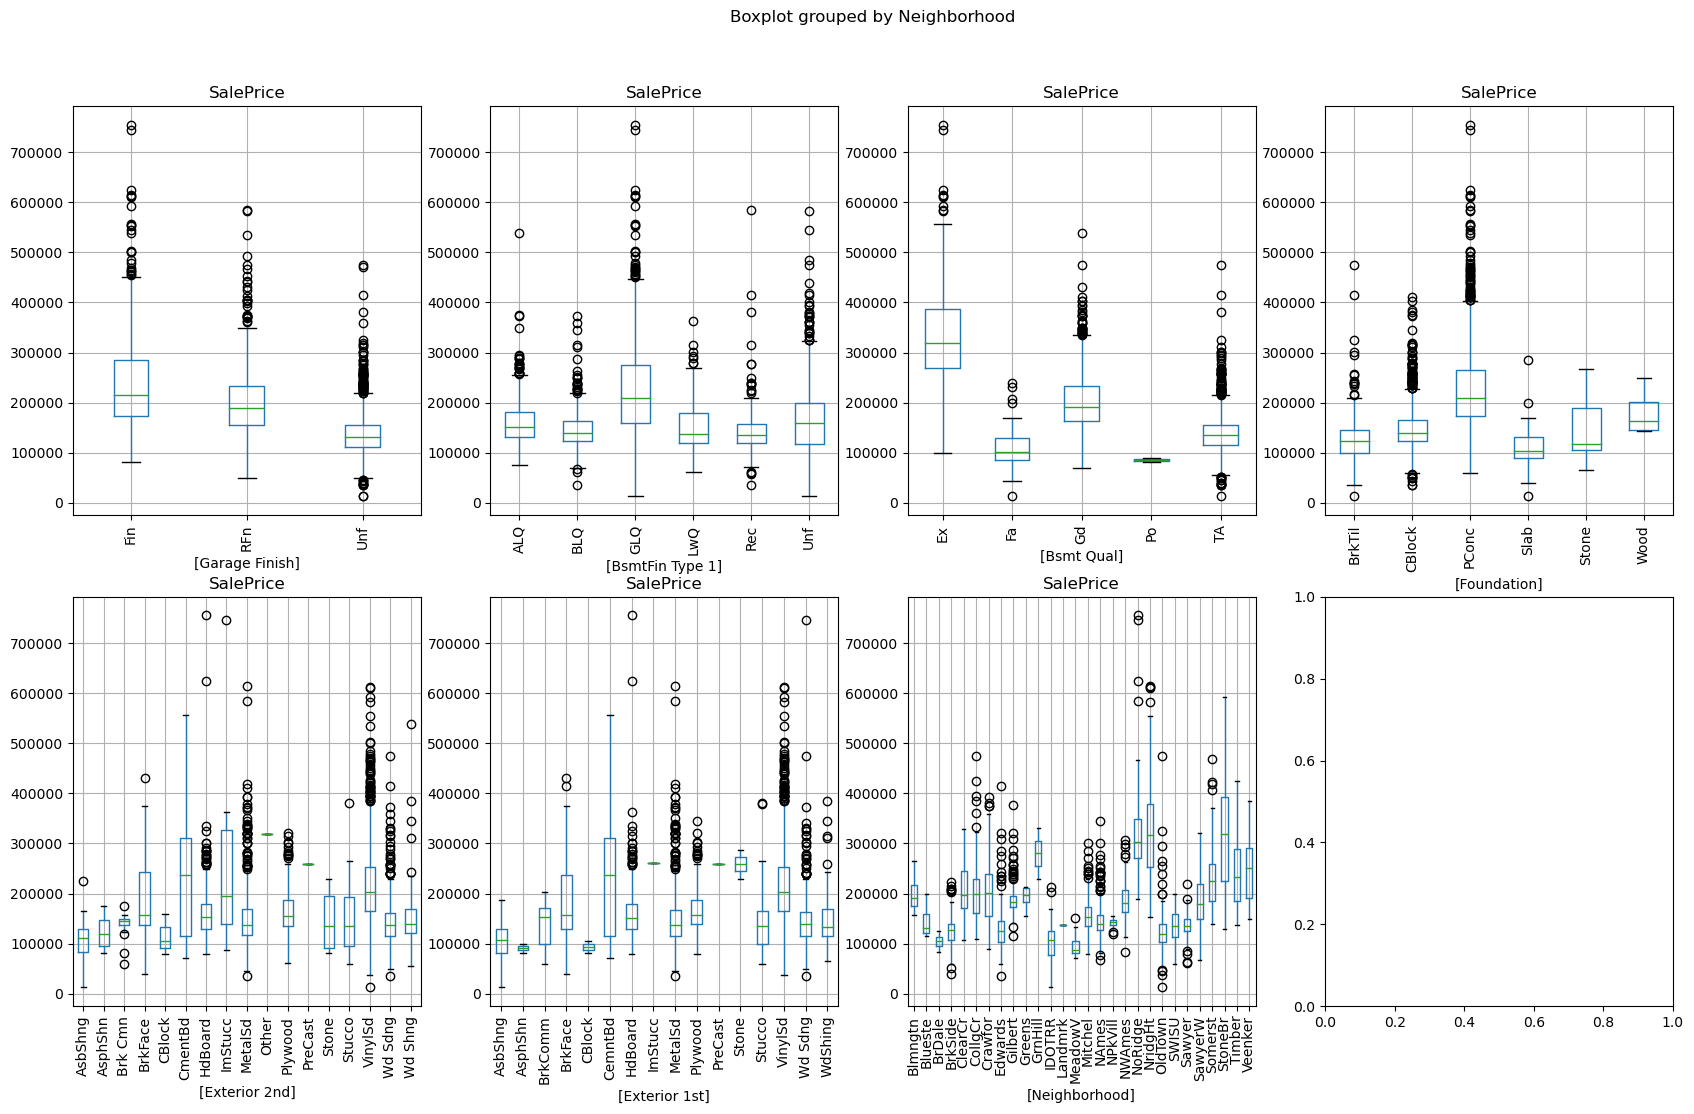

In [91]:
n = len(categorical_important)

r, c = 2,4
fig, ax = plt.subplots(r, c, figsize=(20,12))

for i in range(n):
    feature = categorical_important[::-1][i]
    ax = plt.subplot(r,c,i+1)
    data[[feature,'SalePrice']].boxplot(by=feature, ax=ax, rot=90)

Based on a visual observation we noted the following:
- For `Garage Finish`, those which are `Fin`  have a higher `SalePrice` than those with `RFn` which in turn has a higher `SalePrice` than those with `Unf`
- Houses with `Bsmt Qual` = `Ex` has a much higher median `SalePrice` compared to houses with other values for `Bsmt Qual`

For the other variables, a visual inspection does not reveal any potential relationship to `SalePrice`

Hence based on an EDA on the categorical variables, we will only keep `Garage Finish` and `Bsmt Qual`.  Furthermore, we would encode the categorical values with a numerical value.  We could do that because both `Garage Finish` and `Bsmt Qual` are ordinal meaning there is a natural order attached to the values.

In [92]:
# We keep "Garage Finish" and "Bsmnt Qual" as our variables
# Further more we encode them

def encode_garage_finish(value):
    if value=="Fin":
        return 2
    elif value=="RFn":
        return 1
    else:
        return 0

def encode_bsmt_qual(value):
    if value=="Ex":
        return 1
    else:
        return 0

data["Garage_Finish_Encoded"] = data["Garage Finish"].apply(encode_garage_finish)
data["Bsmt_Qual_Encoded"] = data["Bsmt Qual"].apply(encode_bsmt_qual)

categorical_features_selected = ["Garage_Finish_Encoded", "Bsmt_Qual_Encoded"]

### 5.2 Numerical Variables

So far we have selected two categorical variables and in fact encode them numerically.  Hence, we can now focus only on numerical variables. The objective is similar here, we want to select features or engineer new features so that they can be our attributes in our model later.

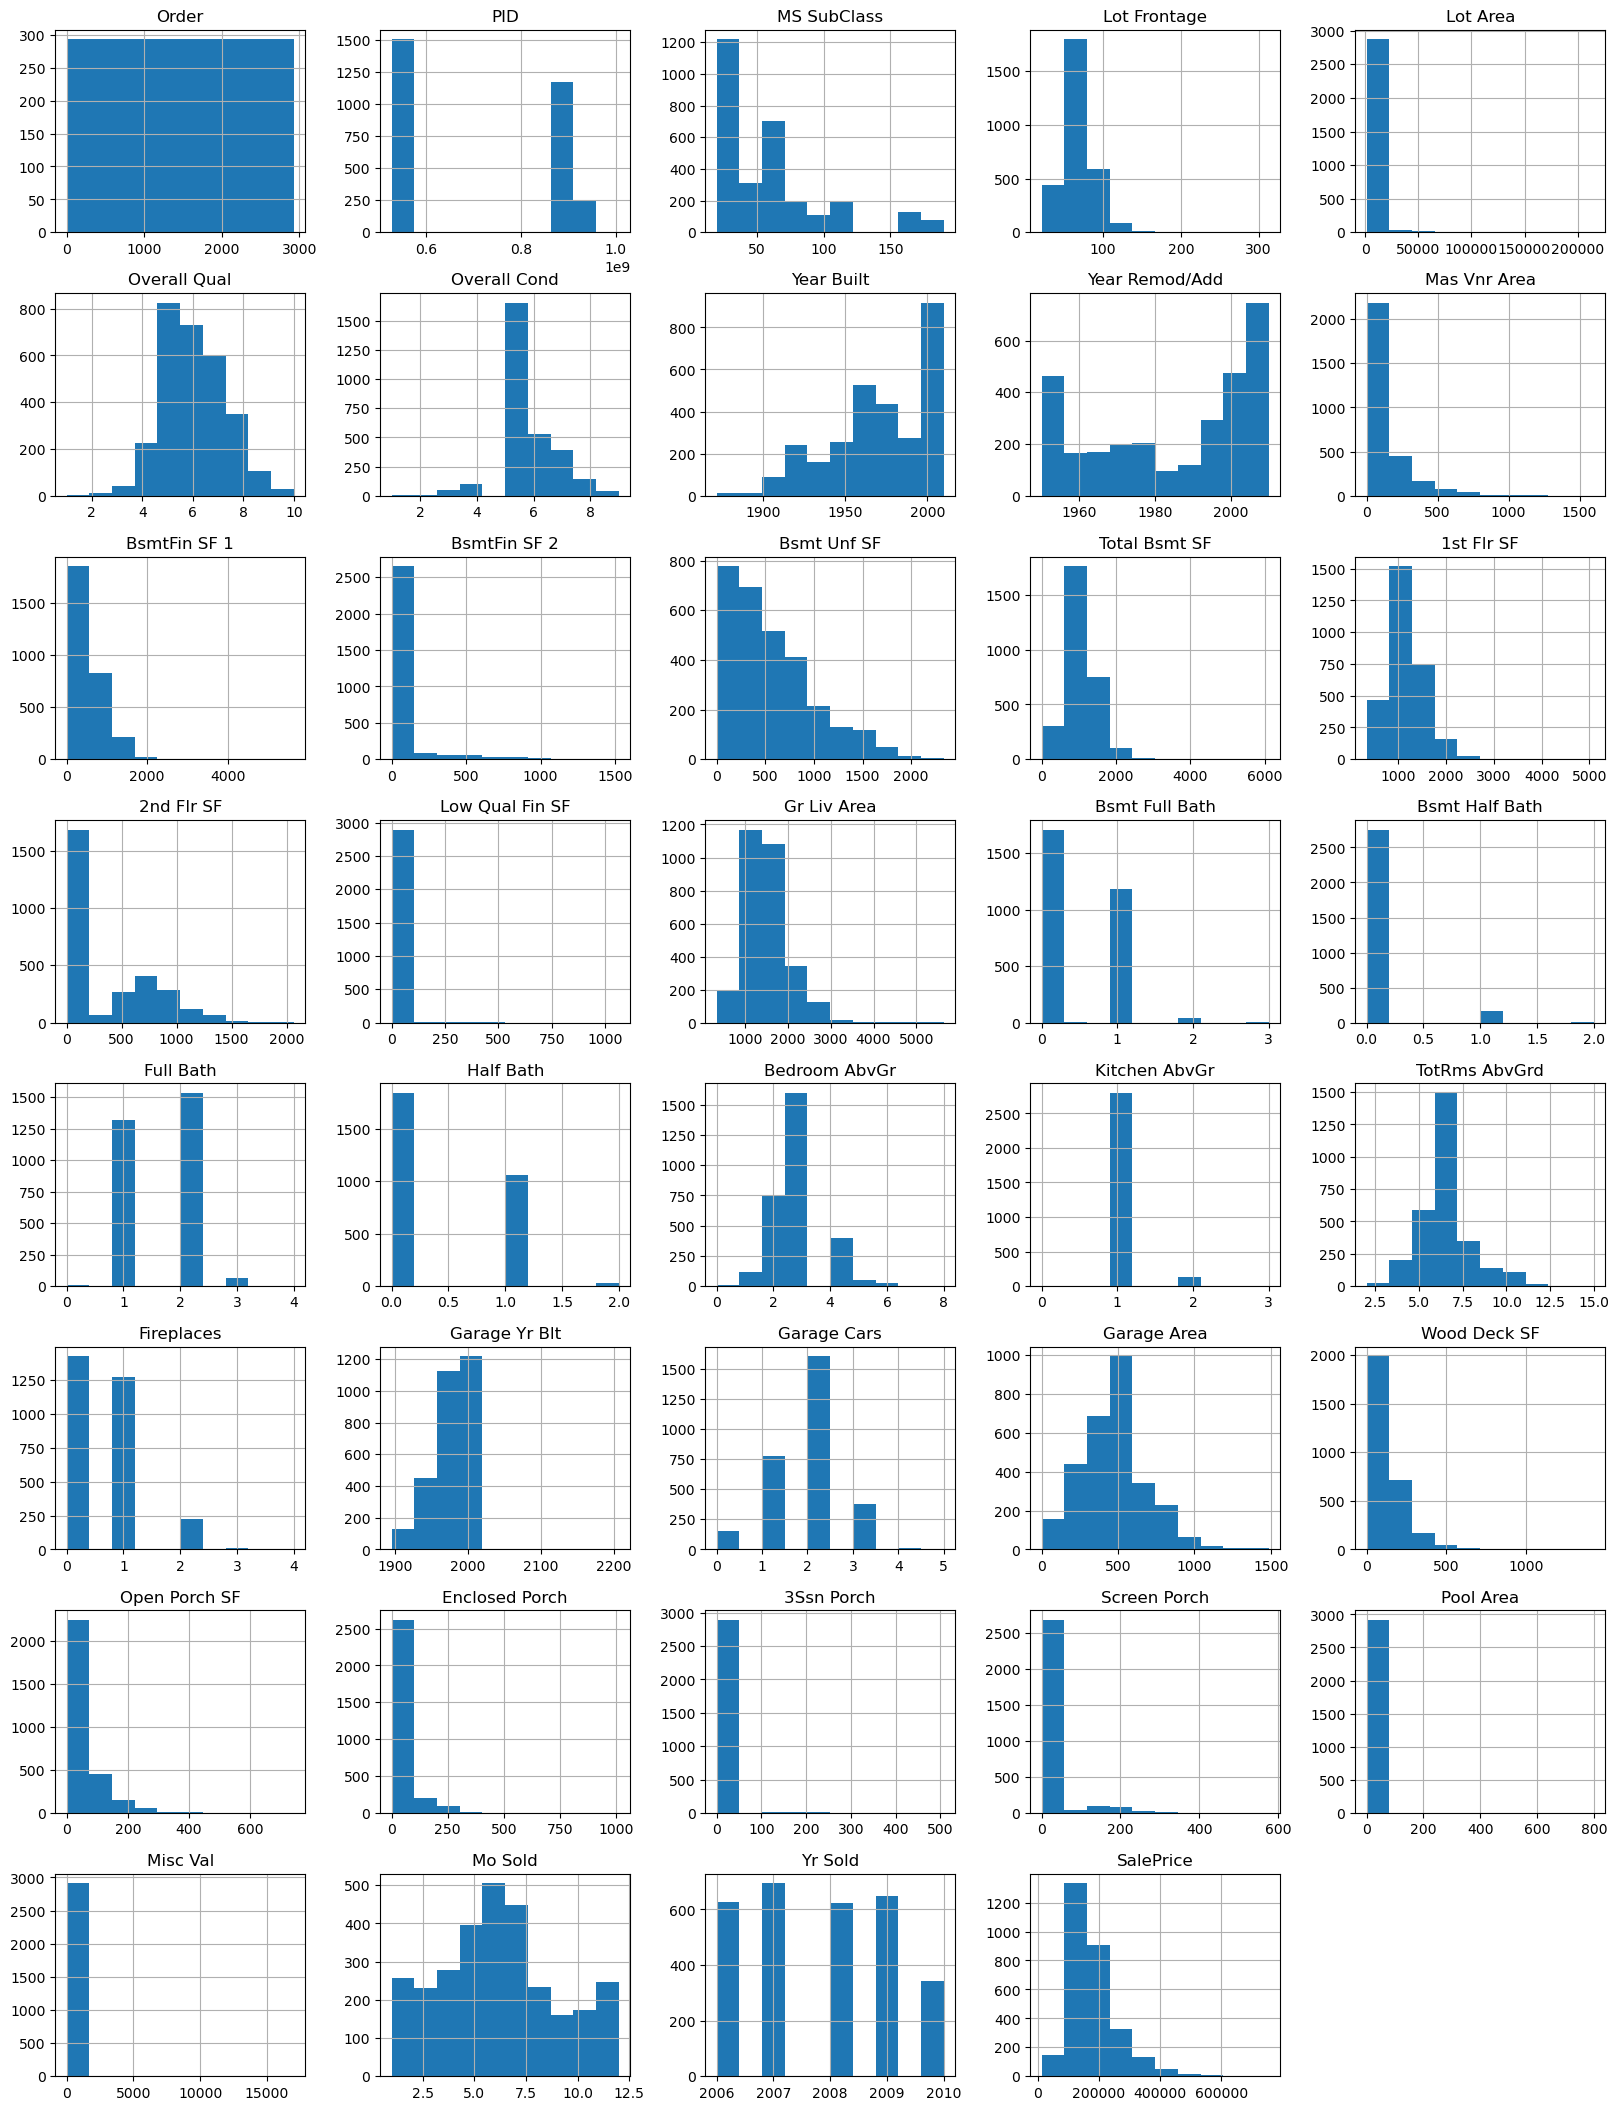

In [93]:
data[numerical_features].hist(layout=(9,5), figsize=(20,30))

plt.show()

Based on a visual observation we noted the following:
- The variable `Order` is an index, hence it would not have explanatory power
- There are several variables which are years, `Year Built`, `Yr Sold`, `Year Remod/Add`, `Garage Yr Blt`.  Instead of using these values directly we would create new features to get more interpretable and meaningful features such as the age of the house, how recently the house was remodified
- The features can be grouped together.  For example, we could sum up `1st Flr SF` and `2nd Flr SF` to get a new feature `Total SF`.  Similarly we could get the total number of bath rooms, and total basement area with finishing.
- There are many variables which are dominated by a small range of values.  In other words, there is little variation in these variables hence they are less likely to explain the variation in `SalePrice`.  We would not select these features.  Examples include `3Ssn Porc`, `Enclosed Porch`, `Kitchen AbvGrd`, `Pool Area`, `Screen Porch` etc  

In [94]:
# create new features

data["Age"] = data["Yr Sold"] - data["Year Built"]
data["Years_After_Remod"] = data["Yr Sold"] - data["Year Remod/Add"]
data["Age_Garage"] = data["Yr Sold"] - data["Garage Yr Blt"]

data["Total Flr SF"] = data["1st Flr SF"] + data["2nd Flr SF"]
data["Total Bath"] = data["Bsmt Full Bath"]+data["Bsmt Half Bath"]+data["Full Bath"]
data["Bsmt Fin SF"] = data["BsmtFin SF 1"]+data["BsmtFin SF 2"]

Based on the observations above, we now select a preliminary set of variables for further EDA.  At this stage, we would want to select *interpretable* variables.  In other words, the variables should be meaningful and relatable for a domain expert.  As such our preliminary variables are `Lot Frontage`,`Lot Area`,`Overall Qual`,`Total Bsmt SF`,`Gr Liv Area`,`TotRms AbvGrd`,`Garage Area`,`Age`, `Total Flr SF`,`Total Bath`,`Bsmt Fin SF`.

In [95]:
features_selected = ["SalePrice","Lot Frontage","Lot Area","Overall Qual","Total Bsmt SF",\
                     "Gr Liv Area","TotRms AbvGrd","Garage Area",\
                     "Age", "Total Flr SF","Total Bath","Bsmt Fin SF"]
data[features_selected].corr()

,SalePrice,Lot Frontage,Lot Area,Overall Qual,Total Bsmt SF,Gr Liv Area,TotRms AbvGrd,Garage Area,Age,Total Flr SF,Total Bath,Bsmt Fin SF
SalePrice,1.000000,0.340751,0.266549,0.799262,0.632105,0.706780,0.495474,0.640385,-0.558907,0.713588,0.576115,0.415177
Lot Frontage,0.340751,1.000000,0.365503,0.198900,0.329620,0.350728,0.324109,0.337700,-0.115813,0.351925,0.182744,0.205076
Lot Area,0.266549,0.365503,1.000000,0.097188,0.253576,0.285599,0.216597,0.212821,-0.024227,0.286875,0.188010,0.212293
Overall Qual,0.799262,0.198900,0.097188,1.000000,0.547088,0.570556,0.380693,0.563445,-0.597021,0.577734,0.482582,0.256453
Total Bsmt SF,0.632105,0.329620,0.253576,0.547088,1.000000,0.444567,0.280635,0.485422,-0.407311,0.448812,0.465605,0.544001
Gr Liv Area,0.706780,0.350728,0.285599,0.570556,0.444567,1.000000,0.807772,0.484857,-0.242510,0.995795,0.485139,0.193619
TotRms AbvGrd,0.495474,0.324109,0.216597,0.380693,0.280635,0.807772,1.000000,0.327276,-0.113074,0.802186,0.339393,0.027920
Garage Area,0.640385,0.337700,0.212821,0.563445,0.485422,0.484857,0.327276,1.000000,-0.479759,0.492075,0.417028,0.296900
Age,-0.558907,-0.115813,-0.024227,-0.597021,-0.407311,-0.242510,-0.113074,-0.479759,1.000000,-0.256909,-0.476426,-0.255951
Total Flr SF,0.713588,0.351925,0.286875,0.577734,0.448812,0.995795,0.802186,0.492075,-0.256909,1.000000,0.491011,0.200511


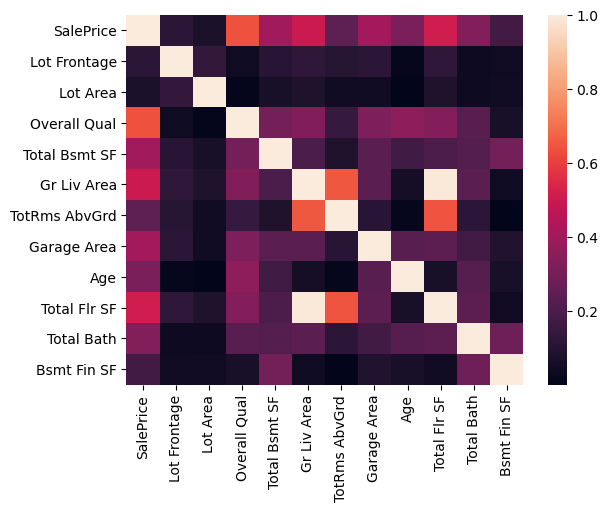

In [96]:
import seaborn as sns
r2 = data[features_selected].corr()**2
sns.heatmap(r2)
plt.show()

The next step is to see if dependent variable `SalePrice` is correlated with our independent variables. We could do it with a correlation table or via correlation heatmap as above.  Note that in the correlation heatmap above, we calculate $r^2$ instead.  The darker the shade the lower the correlation.  We can see, for example, that `Lot Area`, `Lot Frontage` are not quite correlated with `SalePrice`.  Below we write a function to select the features based on a threshold.

In [97]:
# given a dataframe df, and a target variable and threshold
# return all columns in df which are 'highly' correlated to target
# definition of 'high' correlated given by parameter threshold

def corr_features(df, target, threshold):
    corr_features = []
    for feature in df.columns:
        if feature==target: continue
        x = df[feature]
        y = df[target]
        r2 = np.corrcoef(x,y)[0][1]
        if abs(r2)>threshold:
            corr_features.append(feature)
    return corr_features

features_selected = corr_features(data[features_selected], 'SalePrice', 0.5)
print(f"updated selected features: {features_selected}")

updated selected features: ['Overall Qual', 'Total Bsmt SF', 'Gr Liv Area', 'Garage Area', 'Age', 'Total Flr SF', 'Total Bath']


We also want to check that our selected features are not correlated amongst each other.  Any feature that is correlated to others are in a sense *redundant*, hence we would remove them.  Again we could do a quick visual check and see that, for example, `Gr Liv Area` is highly correlated to `Total Flr SF` and hence either is a good candidate to be removed.  Here we have also written a function to eliminate the feature that is the most correlated one by one, untill all features are not correlated.

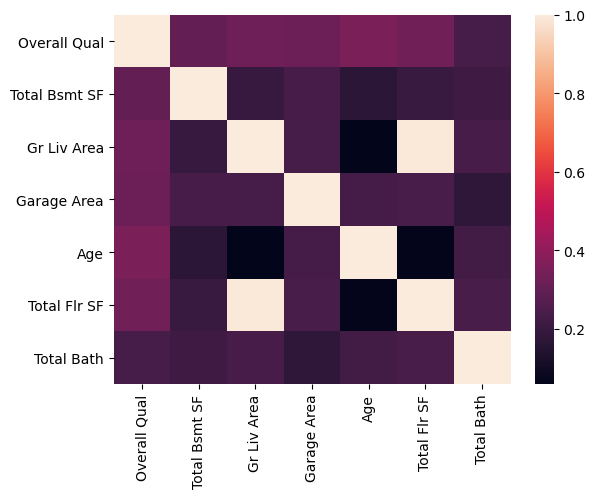

In [98]:
r2 = data[features_selected].corr()**2
sns.heatmap(r2)
plt.show()

In [99]:
# get the feature that has the most number of features
# it is correlated with, beyond certain threshold

def most_corr_feature(df, threshold):
    r2_matrix = abs(df.corr())
    count = r2_matrix[r2_matrix>threshold].count()
    return count.sort_values(ascending=False).index[0]

# return true if all the features are uncorrelated,
# as defined by a threshold

def all_features_uncorr(df, threshold):
    r2_matrix = abs(df.corr())
    n = len(r2_matrix)
    return r2_matrix[r2_matrix>threshold].count().sum()==n

# get a set of uncorrelated features

def get_uncorr_features(df, threshold):
    features = df.columns.tolist()
    while all_features_uncorr(df[features], threshold) == False:
        most_corr_fea = most_corr_feature(df[features], threshold)
        features.remove(most_corr_fea)
    return features

In [100]:
numerical_features_selected = get_uncorr_features(data[features_selected], 0.5)
print(f"Selected numerical features : {numerical_features_selected}")

Selected numerical features : ['Total Bsmt SF', 'Garage Area', 'Age', 'Total Flr SF', 'Total Bath']


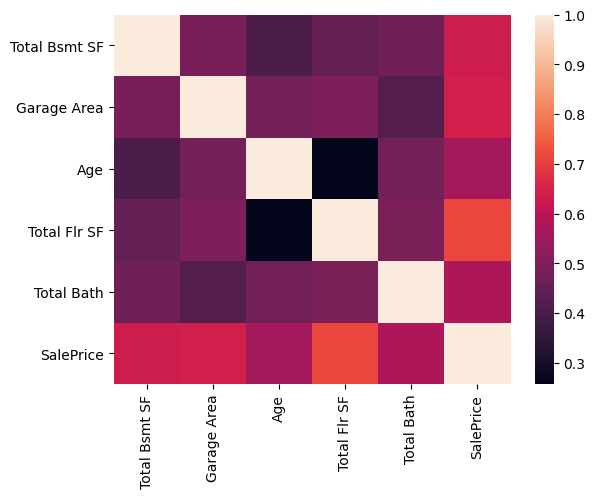

In [101]:
data[numerical_features_selected+['SalePrice']].corr()
r2 = abs(data[numerical_features_selected+['SalePrice']].corr())
sns.heatmap(r2)

plt.show()

Finally we combine the selected categorical and numerical features

In [102]:
features_selected = categorical_features_selected + numerical_features_selected
features_selected

['Garage_Finish_Encoded',
 'Bsmt_Qual_Encoded',
 'Total Bsmt SF',
 'Garage Area',
 'Age',
 'Total Flr SF',
 'Total Bath']

## 6 Model Building

We will build two Linear Regression models based on the selected features.  We split the dataset into train/test set and then fit our model with the train dataset and evaluate the model using the test set.

In [103]:
### train_test_split

from sklearn.model_selection import train_test_split

X = data[features_selected]
y = data[["SalePrice"]]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)


We use the `model_selection` package form `sklearn` to split our dataset randomly into 75/25 i.e. we keep 25% of the dataset for model evaluation purpose.

To perform model fitting, we may also continue to utilise `sklearn`. Specifically for linear models, there are several options available such as the least squares model, Ridge, LASSO, Elastic Net, etc. The models differ in their  _cost functions_. Recall that in the lecture, we determine the optimal parameters of the regression line by minimizing the sum of the squared devivations. The function of the sum of squared deviations is known as the cost function for the least squares method. By designing different cost functions, we could arrive at different models. You may refer to this [link](https://scikit-learn.org/stable/modules/linear_model.html#) for more information.

Here we would fit our data with two commonly used models, namely, `LinearRegression` and `Ridge`. In particular, `LinearRegression` refers to the least squares method, whereas `Ridge` involves slightly more complicated cost function. For each model, we first instantiae a `LinearRegression` or `Ridge` object, and subsequently call the `.fit` method.

In [104]:
## model fitting for linear regression

from sklearn.linear_model import LinearRegression

model1 = LinearRegression().fit(X_train, y_train)
model1_r2 = model1.score(X_train, y_train)
coef1 = model1.coef_
bias1 = model1.intercept_

print("Model 1: Linear Regression ")
print("--------------------------")
print(f"Features : {X_train.columns.tolist()}")
print(f"Coefficients: {coef1[0]}")
print(f"Intercept : {bias1[0]}")
print(f"Coeff of Determination : {model1_r2}")

Model 1: Linear Regression 
--------------------------
Features : ['Garage_Finish_Encoded', 'Bsmt_Qual_Encoded', 'Total Bsmt SF', 'Garage Area', 'Age', 'Total Flr SF', 'Total Bath']
Coefficients: [ 7.21139791e+03  6.44159837e+04  2.57334841e+01  5.19037828e+01
 -4.68443594e+02  6.11041882e+01  7.46487218e+03]
Intercept : 27769.75267525442
Coeff of Determination : 0.7696744483305082


In [105]:
## model fitting for ridge

from sklearn.linear_model import Ridge

model2 = Ridge().fit(X_train, y_train)
model2_r2 = model2.score(X_train, y_train)
coef2 = model2.coef_
bias2 = model2.intercept_

print("Model 2: Ridge Regression")
print("-------------------------")
print(f"Features : {X_train.columns.tolist()}")
print(f"Coefficients: {coef2[0]}")
print(f"Intercept : {bias2[0]}")
print(f"Coeff of Determination : {model2_r2}")

Model 2: Ridge Regression
-------------------------
Features : ['Garage_Finish_Encoded', 'Bsmt_Qual_Encoded', 'Total Bsmt SF', 'Garage Area', 'Age', 'Total Flr SF', 'Total Bath']
Coefficients: [ 7.22142832e+03  6.39084398e+04  2.58050384e+01  5.20012086e+01
 -4.69045326e+02  6.11386151e+01  7.45558034e+03]
Intercept : 27672.57813091061
Coeff of Determination : 0.7696720139134369


## 7 Model Evaluation

Finally we will evaluate our models using the metric *Mean Absolute Error* (MAE) and *Root Mean Squared Error* (RMSE).

In [106]:
## model 1 evaluation

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

# predict based on test set
y_pred = model1.predict(X_test)

# compare with ground truth
mae = mean_absolute_error(y_test, y_pred)
ave = np.mean(y_test["SalePrice"])
rmse = mean_squared_error(y_test, y_pred, squared = False)  # setting squared = False returns the square-root 

print("Model 1 Evaluation")
print("-----------------")
print(f"MAE: {mae:.2f}")
print(f"MAE as % of mean: {mae/ave*100:.1f}%")
print(f"RMSE: {rmse:.2f}")

Model 1 Evaluation
-----------------
MAE: 22747.82
MAE as % of mean: 12.2%
RMSE: 36604.95


In [107]:
## model 2 evaluation

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

# predict based on test set
y_pred = model2.predict(X_test)

# compare with ground truth
mae = mean_absolute_error(y_test, y_pred)
ave = np.mean(y_test["SalePrice"])
rmse = mean_squared_error(y_test, y_pred, squared = False)  # setting squared = False returns the square-root 

print("Model 2 Evaluation")
print("-----------------")
print(f"MAE: {mae:.2f}")
print(f"MAE as % of mean: {mae/ave*100:.1f}%")
print(f"RMSE: {rmse:.2f}")

Model 2 Evaluation
-----------------
MAE: 22750.62
MAE as % of mean: 12.2%
RMSE: 36612.32


Based on the evaluation metrics on the test set for the different models, we would select the model with the best evaluation score. In our case here, however, the evaluation scores of `Linear Regression` and `Ridge` are very close to each other, with `Ridge` being slightly better. 

## 8 Conclusion

In this exercise we have performed an end-to-end data science workflow on the Ames Housing dataset.  We began with data preprocessing ensuring data is clean for further EDA.  We subsequently performed feature selection on both categorical and numerical variables. Upon selecting features that we consider most relevant in predicting the `SalePrice`, we fit our training set on two models and evaluate them on the test set. Based on the test scores, we choose `Ridge` as the final model, which is gives the following predictive model.

\begin{equation}
 SalePrice = 27673 + 7221 \times GarageFinishEncoded + 63908 \times BsmtQualEncoded + 26 \times Total Bsmt SF  + 52 \times Garage Area - 479 \times Age + 61 \times Total Flr SF  + 7456 \times Total Bath 
\end{equation}


Based on the selected model, we found that, on average, prediction is off by an absolute value of around $22,751 which is about 12.2% of the mean. Roughly speaking this means that our predictions are off about 12% on average.

## 9 References
- Dataset: http://www.amstat.org/publications/jse/v19n3/decock/AmesHousing.xls 
- Data Dictionary: http://jse.amstat.org/v19n3/decock/DataDocumentation.txt

<a id="section_b"></a>
## Section B: Classification

>#### Table of Contents
>
>- Introduction
>- Dataset Exploration
>- Data Preprocessing
>- Feature Selection
>    - Categorical Variables
>    - Numerical Variables
>- Model Building
>- Model Evaluation
>- Conclusion
>- References

## 1 Introduction

In this lab we will use a modified version of the Ames Housing Dataset used in Section A. The difference is that the dependent variable in this lab is not the raw sale price, but the class of the sale price (high, medium, low). That is, the `SalePrice` column in the original dataset is replaced with the `SalePriceClass` column. Since the dependent variable is categorical, it is a classification problem.

## 2 Problem Formulation

Home ownership is one of the major life decisions for many people.  Consequently it is important to understand what drives house prices and develop a sound method to be able to predict the fair value of a house.  In this lab we will be tackling the topic of housing prices.  Specifically we use the Ames Housing Dataset as the basis to perform exploratory data analysis and subsequently build a classification model to predict the class of sale price -- high, medium or low.

The Ames Housing Dataset is a rich dataset describing the sale of individual residential property in Ames, Iowa, in the United States from the year 2006 to 2010.  It is a structured tabular dataset with close to 3000 rows and 80 columns.  The variable we want to predict is the housing price class, and there are quite some explanatory variables including material, quality, square footage etc.

In the following sections, we begin with quick exploration of the dataset followed by cleansing and pre-processing the data.  We then perform exploratory data analysis (EDA) to understand the distribution of variables and their correlations.  During the process of EDA we would select and engineer appropriate features that are important in the prediction of housing price.  We finally build two classification models on train dataset and evaluate the models on a test dataset.

## 3 Dataset Exploration

In [136]:
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)
import matplotlib.pyplot as plt
import warnings
import seaborn as sns
warnings.filterwarnings('ignore')

In [137]:
data = pd.read_excel("AmesHousing2.xls")

In [138]:
data.sample(5, random_state=42)

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePriceClass
1357,1358,903427090,70,RM,NaN,5100,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,OldTown,Norm,Norm,1Fam,2Story,8,7,1925,1996,Hip,CompShg,Stucco,Wd Shng,None,0.0,TA,Gd,PConc,TA,TA,No,Unf,0.0,Unf,0.0,588.0,588.0,GasA,Fa,Y,SBrkr,833,833,0,1666,0.0,0.0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1925.0,Unf,1.0,228.0,TA,TA,Y,192,63,0,0,0,0,NaN,MnPrv,NaN,0,6,2008,WD,Normal,2
2367,2368,527450460,160,RM,21.0,1890,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,BrDale,Norm,Norm,Twnhs,2Story,6,7,1972,1972,Gable,CompShg,HdBoard,HdBoard,BrkFace,380.0,TA,TA,CBlock,TA,TA,No,ALQ,282.0,Unf,0.0,212.0,494.0,GasA,Ex,Y,SBrkr,494,536,0,1030,0.0,0.0,1,1,3,1,TA,6,Typ,0,NaN,Detchd,1973.0,Unf,1.0,264.0,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,7,2006,WD,Normal,1
2822,2823,908128100,60,RL,62.0,7162,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Edwards,Norm,Norm,1Fam,2Story,7,5,2003,2004,Hip,CompShg,HdBoard,Stucco,BrkFace,190.0,Gd,TA,PConc,Gd,TA,No,Unf,0.0,Unf,0.0,796.0,796.0,GasA,Ex,Y,SBrkr,806,918,0,1724,0.0,0.0,2,1,3,1,Gd,8,Typ,1,Gd,BuiltIn,2003.0,Fin,2.0,616.0,TA,TA,Y,168,57,0,0,0,0,NaN,NaN,NaN,0,5,2006,WD,Normal,2
2126,2127,907135180,20,RL,60.0,8070,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,1Story,4,5,1994,1995,Gable,CompShg,VinylSd,VinylSd,None,0.0,TA,TA,PConc,Gd,TA,No,GLQ,588.0,Unf,0.0,402.0,990.0,GasA,Ex,Y,SBrkr,990,0,0,990,1.0,0.0,1,0,3,1,TA,5,Typ,0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal,2
1544,1545,910200080,30,RM,50.0,7000,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,IDOTRR,Norm,Norm,1Fam,1Story,6,8,1926,1998,Gable,CompShg,VinylSd,VinylSd,None,0.0,TA,Gd,BrkTil,TA,TA,No,Rec,299.0,GLQ,40.0,555.0,894.0,GasA,TA,Y,SBrkr,919,0,0,919,1.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Detchd,1926.0,Unf,1.0,195.0,TA,TA,P,0,0,116,0,0,0,NaN,MnPrv,NaN,0,7,2008,WD,Normal,2


A quick peek gives us the following observations:
- `Order` is an index which we can ignore
- there are some missing values that need to be dealt with
- there are both categorical and numerical variables
- note that `SalePriceClass` is a categorical variable with values 1, 2, 3, representing three classes of the sale price (high, medium, low).

A bar plot on `SalePriceClass` shows that the values are evenly distributed among the three classes

<AxesSubplot:xlabel='SalePriceClass'>

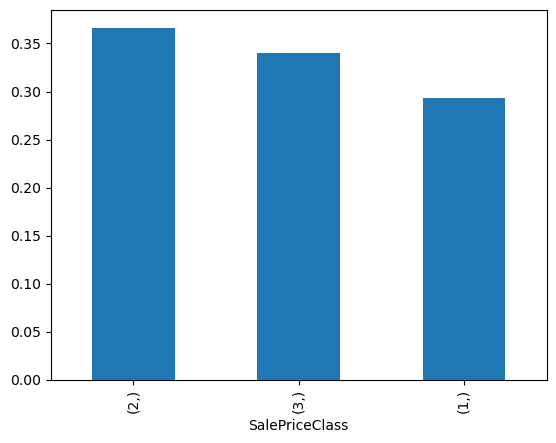

In [139]:
data[['SalePriceClass']].astype(str).value_counts(normalize=True).plot(kind='bar')

In [140]:
n_rows, n_cols = data.shape
n_rows, n_cols

(2930, 82)

There are a total of 2930 observations with 82 columns, i.e., 1 target variable and 81 independent variables.

In [141]:
# Get a list of numerical, categorical features

datatypes = data.dtypes
print(datatypes)

categorical_features = datatypes[datatypes=="object"].index
numerical_features = datatypes[datatypes!="object"].index

Order               int64
PID                 int64
MS SubClass         int64
MS Zoning          object
Lot Frontage      float64
                   ...   
Mo Sold             int64
Yr Sold             int64
Sale Type          object
Sale Condition     object
SalePriceClass      int64
Length: 82, dtype: object


In [142]:
print(f"# categorical features: {len(categorical_features)}")
print(f"# numerical features: {len(numerical_features)}")

# categorical features: 43
# numerical features: 39


## 4 Data Preprocessing

We now look into issue of missing data.

In [143]:
# calculate percentage of non-NaN data

missing_percent = 1 - data.count() / n_rows


# filter for columns with non-zero count of NaN data

missing_percent[missing_percent > 0.0]

print(f"# features with missing data : {len(missing_percent[missing_percent>0.0])}")

# features with missing data : 27


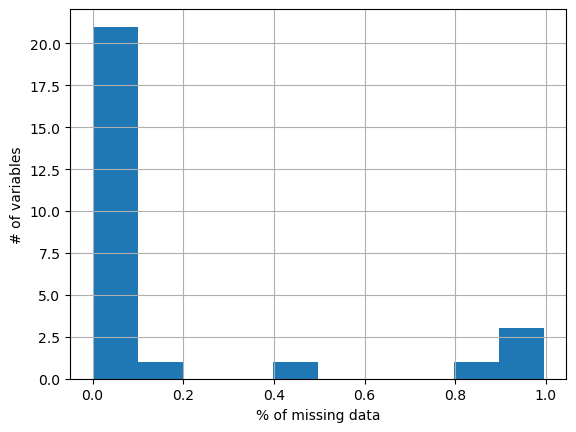

In [144]:
missing_percent[missing_percent>0.].hist()

plt.xlabel("% of missing data")
plt.ylabel("# of variables")
plt.show()

We will drop columns if missing data is more than 20%.  For those with less than 10% missing data, we would impute with mode or mean.

In [145]:
# get columns with > 20% missing data, and drop in-place

threshold = 0.20
cols_to_drop = missing_percent[missing_percent>threshold].index

print(f"Columns to drop: {cols_to_drop}")

data.drop(columns=cols_to_drop, inplace=True)

Columns to drop: Index(['Alley', 'Fireplace Qu', 'Pool QC', 'Fence', 'Misc Feature'], dtype='object')


In [146]:
missing_percent[missing_percent>threshold].index

Index(['Alley', 'Fireplace Qu', 'Pool QC', 'Fence', 'Misc Feature'], dtype='object')

In [147]:
# get categorical variables with < 10% missing data and impute with mode

threshold = 0.10

cols_to_impute = missing_percent[(missing_percent<threshold)&(missing_percent>0.0)].index

cols_to_impute_mode = list(set(cols_to_impute) & set(categorical_features))

print(f"Categorical columns to impute with mode: {cols_to_impute_mode}\n")

for col in cols_to_impute_mode:
    data[col].fillna(data[col].mode().iloc[0], inplace=True)

# confirm no missing values

print(data[cols_to_impute_mode].count())

Categorical columns to impute with mode: ['Mas Vnr Type', 'Garage Type', 'Garage Finish', 'Bsmt Cond', 'Bsmt Qual', 'BsmtFin Type 2', 'Garage Cond', 'Garage Qual', 'Bsmt Exposure', 'Electrical', 'BsmtFin Type 1']

Mas Vnr Type      2930
Garage Type       2930
Garage Finish     2930
Bsmt Cond         2930
Bsmt Qual         2930
BsmtFin Type 2    2930
Garage Cond       2930
Garage Qual       2930
Bsmt Exposure     2930
Electrical        2930
BsmtFin Type 1    2930
dtype: int64


In [148]:
# get numerical variables with < 10% missing data and impute with mean

threshold = 0.10

cols_to_impute = missing_percent[(missing_percent<threshold)&(missing_percent>0.0)].index

cols_to_impute_mean = list(set(cols_to_impute) & set(numerical_features))

print(f"Numerical columns to impute with mode: {cols_to_impute_mean}\n")

for col in cols_to_impute_mean:
    data[col].fillna(data[col].mean(), inplace=True)

# confirm no missing data

print(data[cols_to_impute_mean].count())

Numerical columns to impute with mode: ['BsmtFin SF 2', 'Bsmt Half Bath', 'Total Bsmt SF', 'Garage Cars', 'Bsmt Unf SF', 'BsmtFin SF 1', 'Garage Area', 'Bsmt Full Bath', 'Mas Vnr Area', 'Garage Yr Blt']

BsmtFin SF 2      2930
Bsmt Half Bath    2930
Total Bsmt SF     2930
Garage Cars       2930
Bsmt Unf SF       2930
BsmtFin SF 1      2930
Garage Area       2930
Bsmt Full Bath    2930
Mas Vnr Area      2930
Garage Yr Blt     2930
dtype: int64


In [149]:
missing_percent[(missing_percent>.10) & (missing_percent<.2)]

Lot Frontage    0.167235
dtype: float64

Finally we need to handle the remaining missing column `Lot Frontage` which has 16% of missing data.  We plot a histogram of the variable and found that it is unimodal.  Hence imputing it with mean would be a reasonable choice.

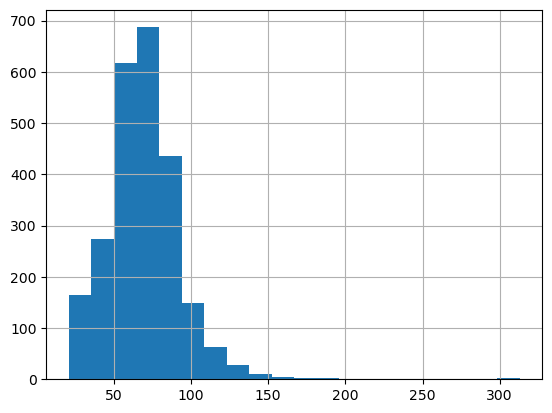

In [150]:
data["Lot Frontage"].hist(bins=20)
plt.show()

In [151]:
data["Lot Frontage"].fillna(data["Lot Frontage"].mean(), inplace=True)

# confirm no missing data

missing_data = 1. - data.count() / n_rows
missing_data[missing_data>0.]

Series([], dtype: float64)

## 5 Feature Selection

In this section we will perform EDA to understand the data.  The main outcome of this exercise is to help us do feature selection and feature engineering.  In other words, we want to design a set of attributes which could be used as our independent variables to predict the `SalePrice` in our model later.

In [152]:
datatypes = data.dtypes
categorical_features = datatypes[datatypes=="object"].index
numerical_features = datatypes[datatypes!="object"].index

### 5.1 Categorical Variables

First, we investigate the distribution of each variable by plotting barplots as below

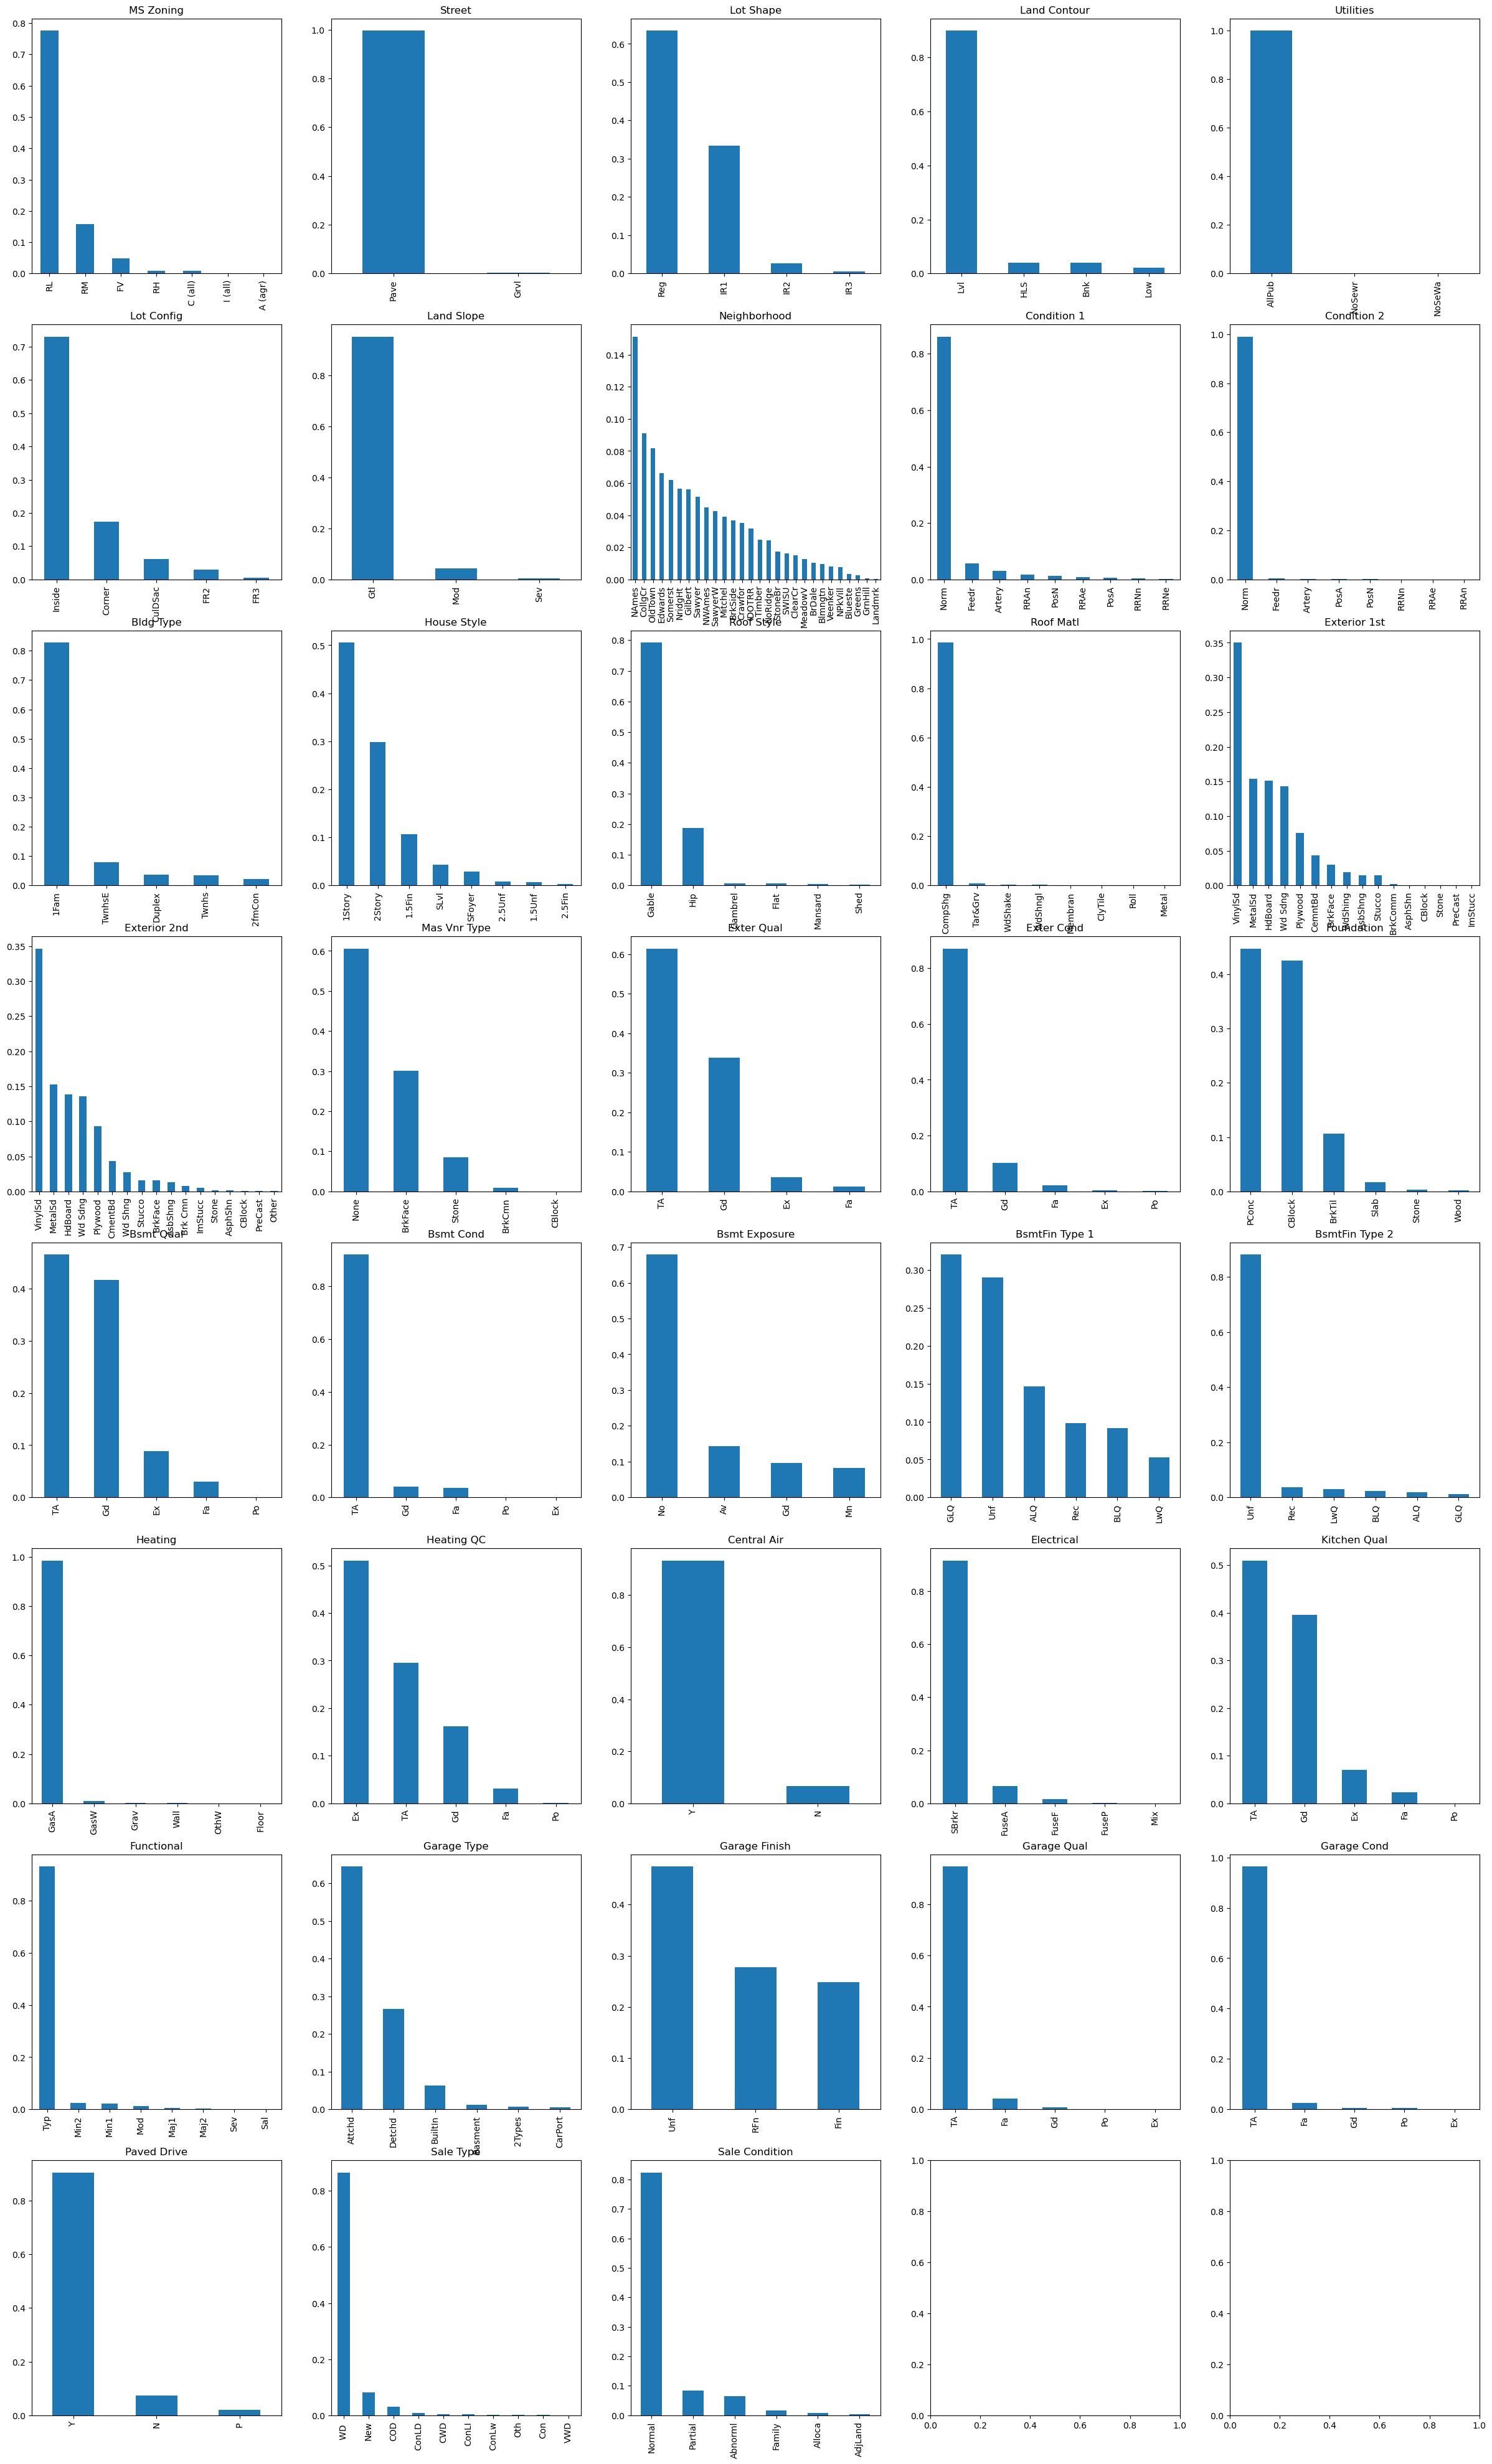

In [153]:
n = len(categorical_features)

r, c = 8,5
fig, ax = plt.subplots(r, c, figsize=(30,50))

for i in range(n):
    feature = categorical_features[i]
    ax = plt.subplot(r,c,i+1)
    ax.set_title(feature)
    data[feature].value_counts(normalize=True).plot(kind='bar')

plt.show()

We observed that many of the variables have a dominant value.  The lack of variation in these variables means that these variables are likey to have little explanatory power on the variation in `SalePriceClass`.  Hence we will not select these features.  The criteria we use is that we will not select features where its mode has a frequency of more than 50%. 

In [154]:
# get 'important' categorical features i.e. those with mode having freq < 50%

categorical_important = []

for feature in categorical_features:
    if feature == 'SalePriceClass':
        continue
    highest = data[feature].value_counts(normalize=True)[0]
    if highest<0.5:
        categorical_important.append(feature)

print(f"Variables with mode contributing <50% are : {categorical_important}")

Variables with mode contributing <50% are : ['Neighborhood', 'Exterior 1st', 'Exterior 2nd', 'Foundation', 'Bsmt Qual', 'BsmtFin Type 1', 'Garage Finish']


Based on the criteria we would keep these seven categorical variables.  We next look into how `SalePriceClass` is related to these variables.  For each categorical variable, we plot a stacked bar plot and see the distribution of `SalePriceClass` with respect to the categorical variable

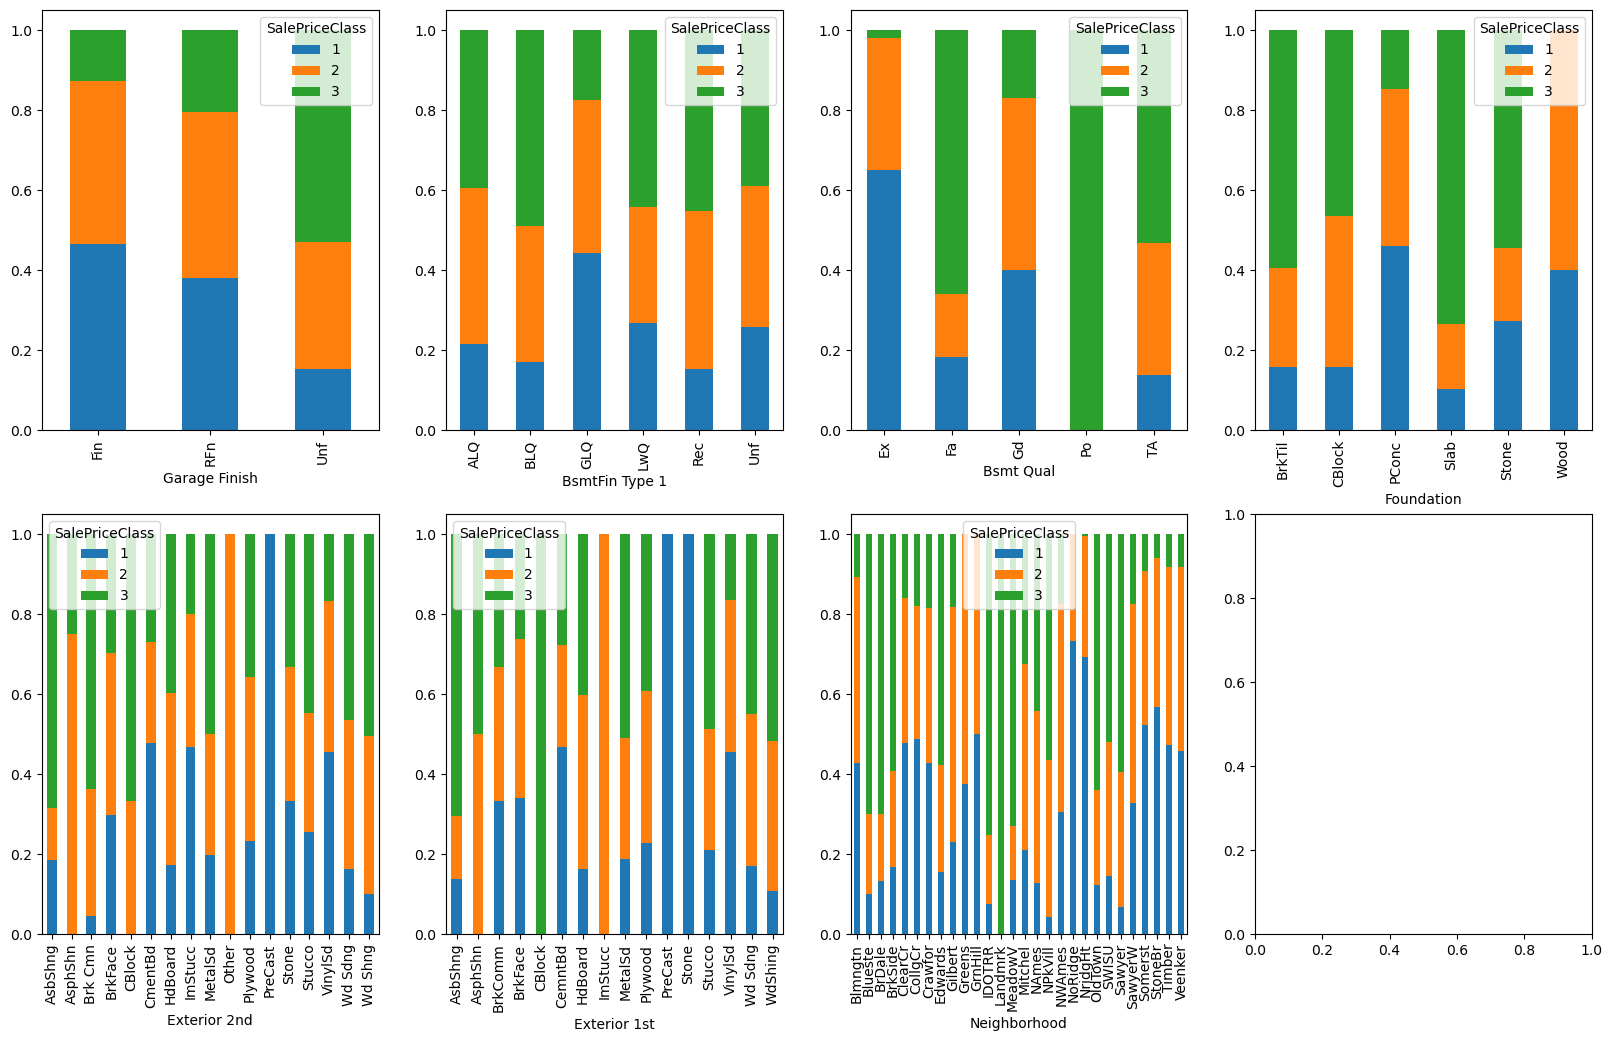

In [155]:
n = len(categorical_important)
r, c = 2,4
fig, ax = plt.subplots(r, c, figsize=(20,12))

for i in range(n):
    feature = categorical_important[::-1][i]
    ax = plt.subplot(r,c,i+1)
    pd.crosstab(data[feature], data["SalePriceClass"], normalize="index").plot.bar(stacked=True, ax=ax)

Based on a visual observation we noted the following:
- For `Garage Finish`, those which are `Fin`  have a higher proportion of class 1 for `SalePriceClass` than those with `RFn` which in turn has a higher proportion of class 1 for `SalePriceClass` than those with `Unf`
- Houses with `Bsmt Qual` = `Ex` has a much higher percentage of class 1 for `SalePriceClass` compared to houses with other values for `Bsmt Qual`

For the other variables, a visual inspection does not reveal any potential relationship to `SalePriceClass`

Hence based on an EDA on the categorical variables, we will only keep `Garage Finish` and `Bsmt Qual`.  Furthermore, we would encode the categorical values with a numerical value.  We could do that because both `Garage Finish` and `Bsmt Qual` are ordinal meaning there is a natural order attached to the values.

In [156]:
# We keep "Garage Finish" and "Bsmnt Qual" as our variables
# Further more we encode them

def encode_garage_finish(value):
    if value=="Fin":
        return 2
    elif value=="RFn":
        return 1
    else:
        return 0

def encode_bsmt_qual(value):
    if value=="Ex":
        return 1
    else:
        return 0

data["Garage_Finish_Encoded"] = data["Garage Finish"].apply(encode_garage_finish)
data["Bsmt_Qual_Encoded"] = data["Bsmt Qual"].apply(encode_bsmt_qual)

categorical_features_selected = ["Garage_Finish_Encoded", "Bsmt_Qual_Encoded"]

### 5.2 Numerical Variables

So far we have selected two categorical variables and in fact encode them numerically.  Hence, we can now focus only on numerical variables. The objective is similar here, we want to select features or engineer new features so that they can be our attributes in our model later.

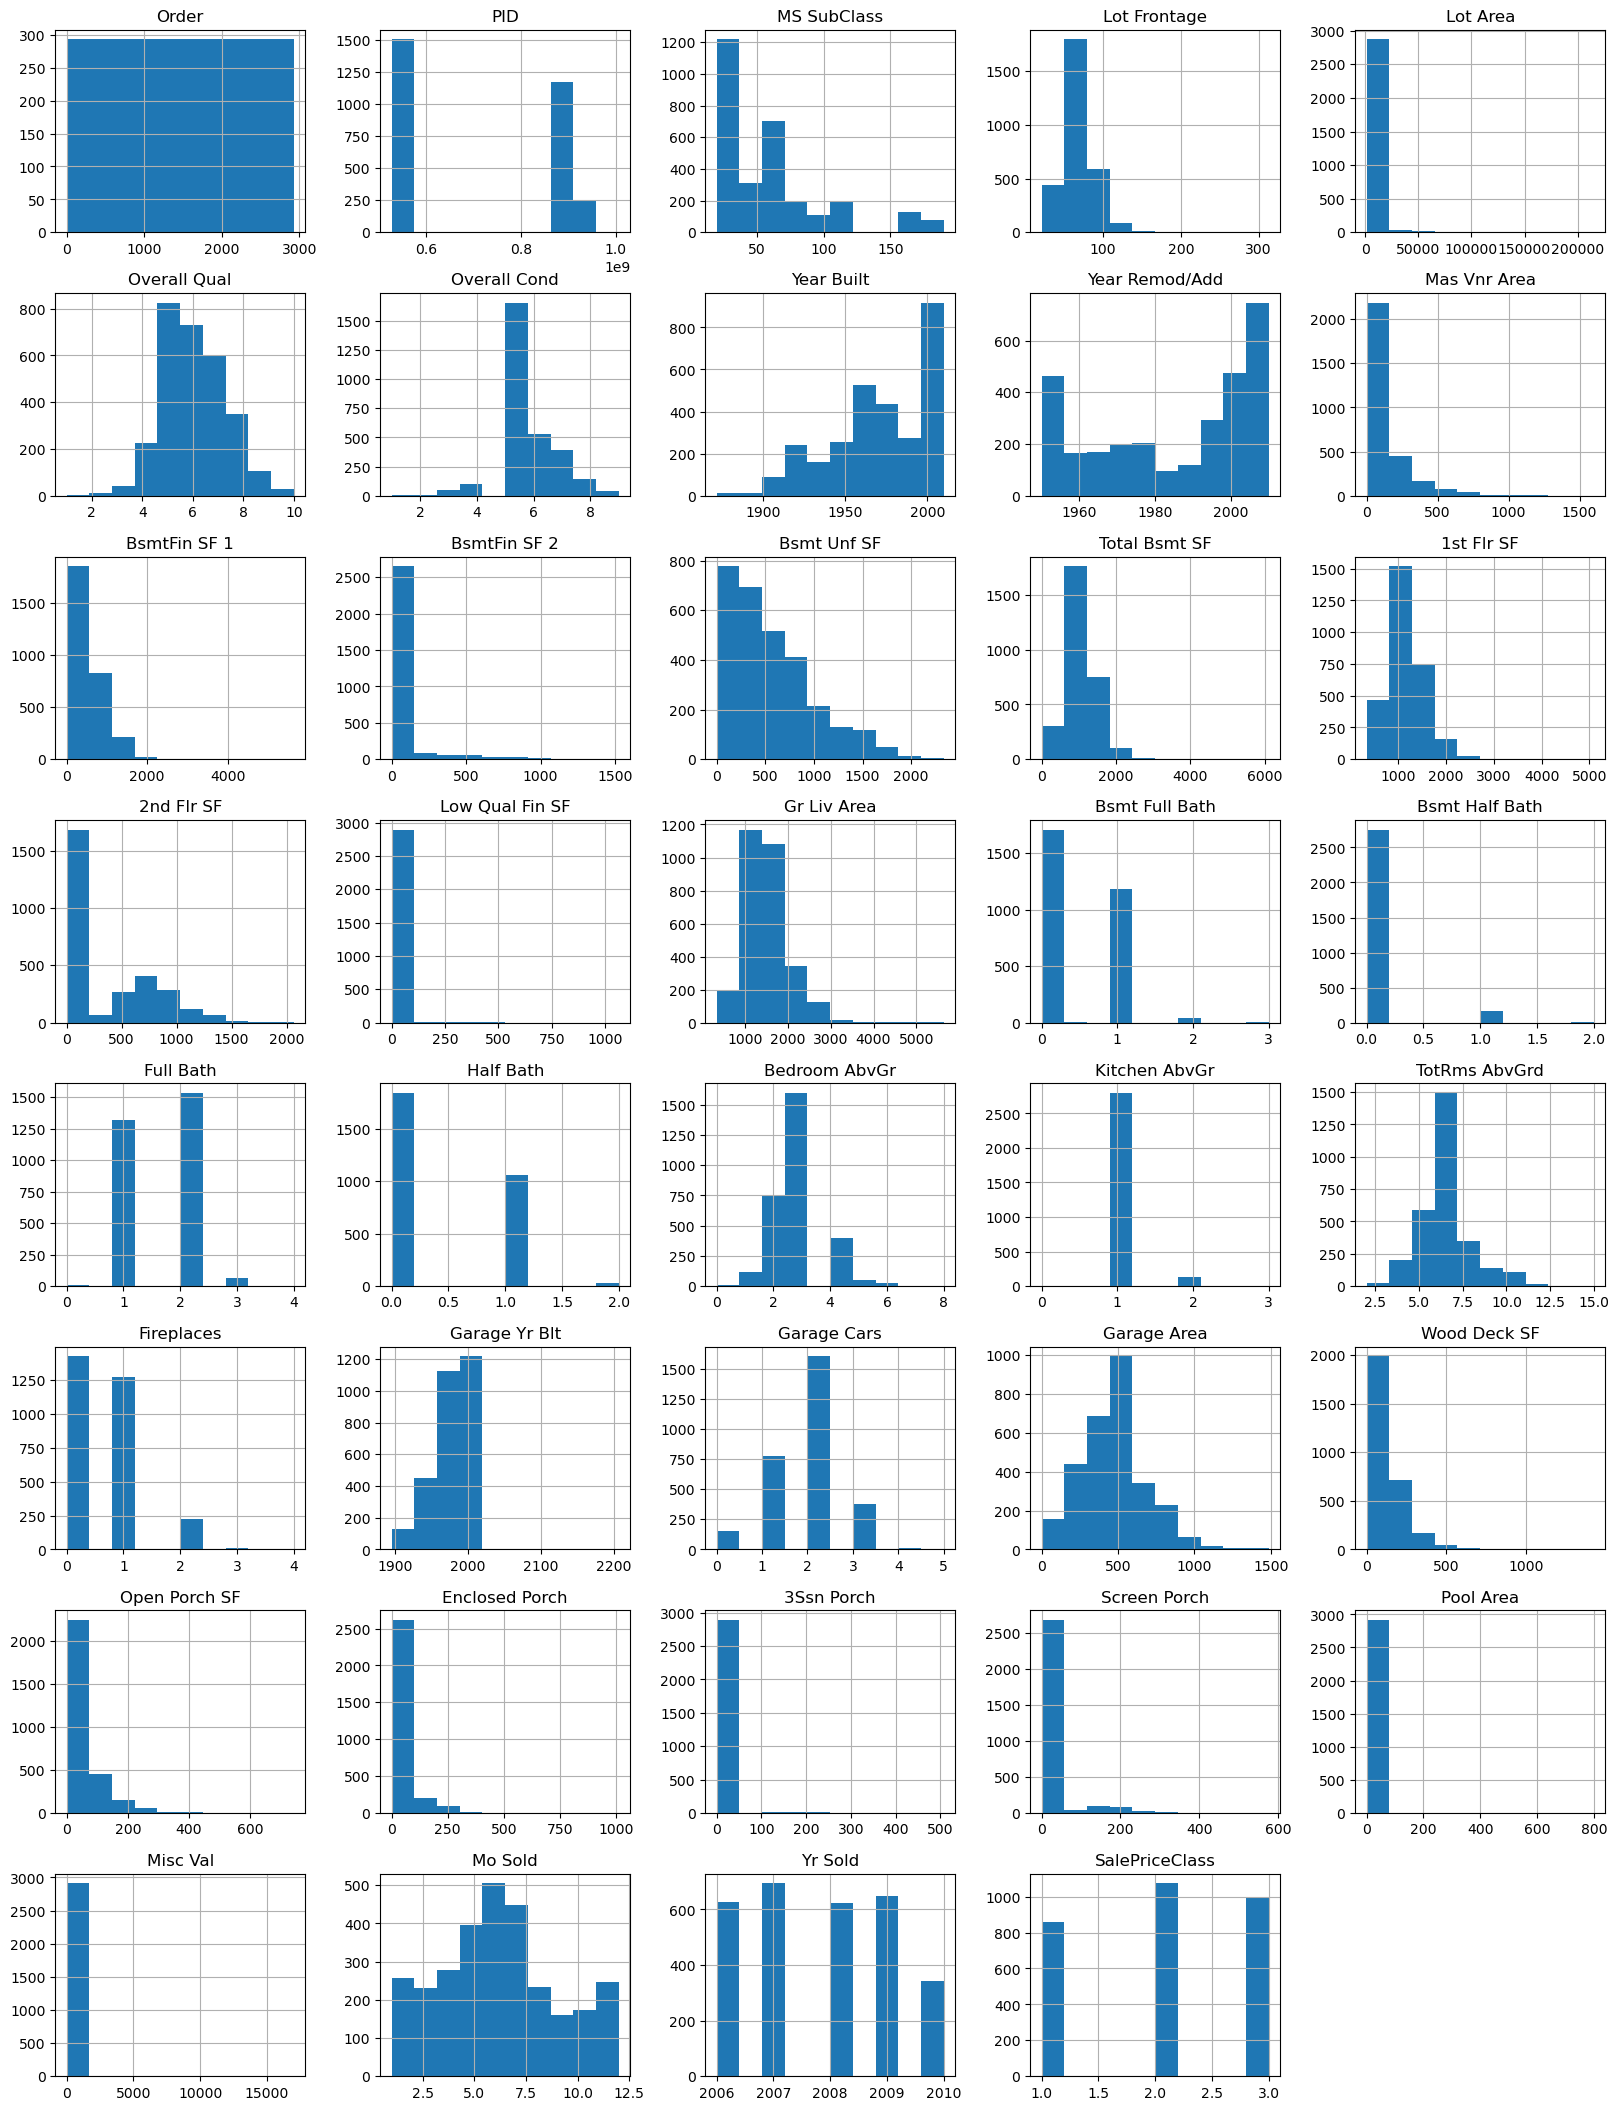

In [157]:
data[numerical_features].hist(layout=(9,5), figsize=(20,30))

plt.show()

Based on a visual observation we noted the following:
- The variable `Order` is an index, hence it would not have explanatory power
- There are several variables which are years, `Year Built`, `Yr Sold`, `Year Remod/Add`, `Garage Yr Blt`.  Instead of using these values directly we would create new features to get more interpretable and meaningful features such as the age of the house, how recently the house was remodified
- The features can be grouped together.  For example, we could sum up `1st Flr SF` and `2nd Flr SF` to get a new feature `Total SF`.  Similarly we could get the total number of bath rooms, and total basement area with finishing.
- There are many variables which are dominated by a small range of values.  In other words, there is little variation in these variables hence they are less likely to predict `SalePriceClass`.  We would not select these features.  Examples include `3Ssn Porc`, `Enclosed Porch`, `Kitchen AbvGrd`, `Pool Area`, `Screen Porch` etc  

In [158]:
# create new features

data["Age"] = data["Yr Sold"] - data["Year Built"]
data["Years_After_Remod"] = data["Yr Sold"] - data["Year Remod/Add"]
data["Age_Garage"] = data["Yr Sold"] - data["Garage Yr Blt"]

data["Total Flr SF"] = data["1st Flr SF"] + data["2nd Flr SF"]
data["Total Bath"] = data["Bsmt Full Bath"]+data["Bsmt Half Bath"]+data["Full Bath"]
data["Bsmt Fin SF"] = data["BsmtFin SF 1"]+data["BsmtFin SF 2"]

Based on the observations above, we now select a preliminary set of variables for further EDA.  At this stage, we would want to select *interpretable* variables.  In other words, the variables should be meaningful and relatable for a domain expert.  As such our preliminary variables are `Lot Frontage`,`Lot Area`,`Overall Qual`,`Total Bsmt SF`,`Gr Liv Area`,`TotRms AbvGrd`,`Garage Area`,`Age`, `Total Flr SF`,`Total Bath`,`Bsmt Fin SF`.

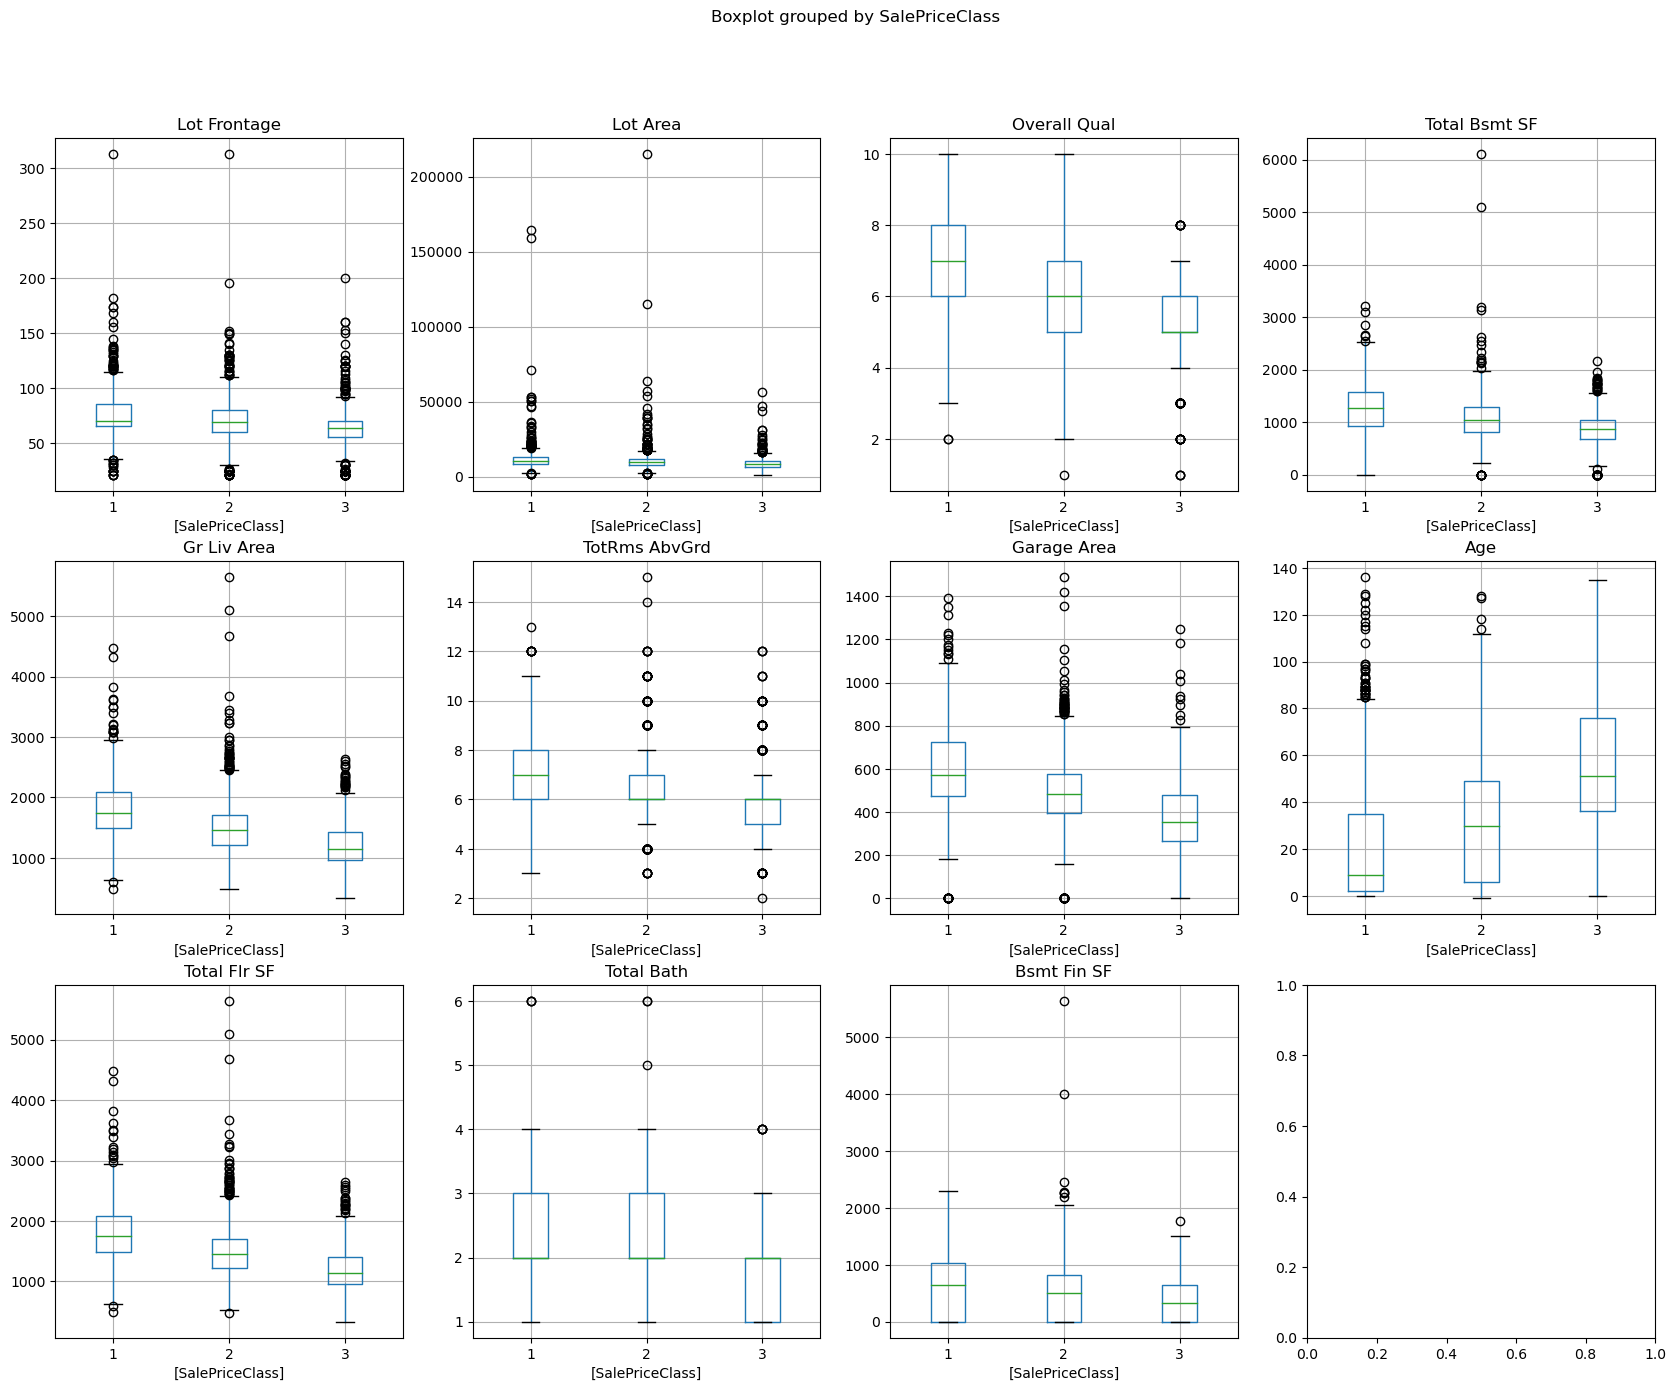

In [159]:
features_selected = ["Lot Frontage","Lot Area","Overall Qual","Total Bsmt SF",\
                     "Gr Liv Area","TotRms AbvGrd","Garage Area",\
                     "Age", "Total Flr SF","Total Bath","Bsmt Fin SF"]

n = len(features_selected)

r, c = 3,4
fig, ax = plt.subplots(r, c, figsize=(20,16))

for i in range(n):
    feature = features_selected[i]
    ax = plt.subplot(r,c,i+1)
    ax.set_title(feature)
    data[['SalePriceClass',feature]].boxplot(by='SalePriceClass', ax=ax)

plt.show()

The next step is to see if dependent variable `SalePriceClass` is correlated with the features. We will do this only visually in this case - if the median values along with the IQR increase or decrease as we move from one class to another class, then we consider that the feature is corrleated to 'SalePriceClass'  

Based on the criteria, the selected features are 'Overal Qual', 'Total Bsmt SF', 'Gr Liv Area', 'Garage Area', 'Age' and 'Total Flr SF'

In [160]:
features_selected = ['Overall Qual', 'Total Bsmt SF', 'Gr Liv Area', 'Garage Area', 'Age', 'Total Flr SF']
print(f"updated selected features: {features_selected}")

updated selected features: ['Overall Qual', 'Total Bsmt SF', 'Gr Liv Area', 'Garage Area', 'Age', 'Total Flr SF']


We also want to check that our selected features are not correlated amongst each other.  Any feature that is correlated to others are in a sense *redundant*, hence we would remove them.  Again we could do a quick visual check and see that, for example, `Gr Liv Area` is highly correlated to `Total Flr SF` and hence either is a good candidate to be removed.  Here we have also written a function to eliminate the feature that is the most correlated one by one, untill all features are not correlated.

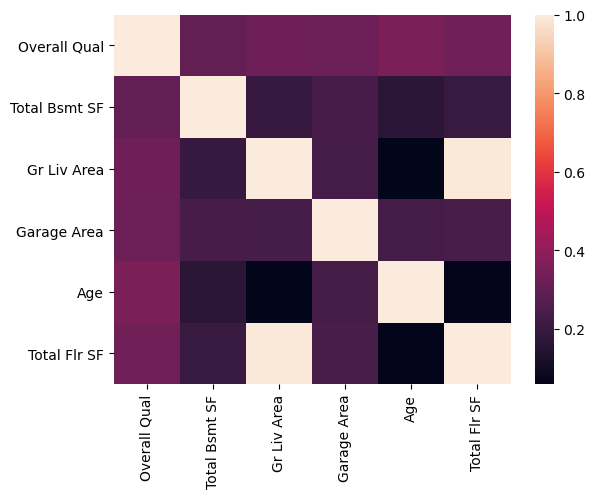

In [161]:
r2 = data[features_selected].corr()**2
sns.heatmap(r2)
plt.show()

In [162]:
# get the feature that has the most number of features
# it is correlated with, beyond certain threshold

def most_corr_feature(df, threshold):
    r2_matrix = abs(df.corr())
    count = r2_matrix[r2_matrix>threshold].count()
    return count.sort_values(ascending=False).index[0]

# return true if all the features are uncorrelated,
# as defined by a threshold

def all_features_uncorr(df, threshold):
    r2_matrix = abs(df.corr())
    n = len(r2_matrix)
    return r2_matrix[r2_matrix>threshold].count().sum()==n

# get a set of uncorrelated features

def get_uncorr_features(df, threshold):
    features = df.columns.tolist()
    while all_features_uncorr(df[features], threshold) == False:
        most_corr_fea = most_corr_feature(df[features], threshold)
        features.remove(most_corr_fea)
    return features

In [163]:
numerical_features_selected = get_uncorr_features(data[features_selected], 0.5)
print(f"Selected numerical features : {numerical_features_selected}")

Selected numerical features : ['Total Bsmt SF', 'Garage Area', 'Age', 'Total Flr SF']


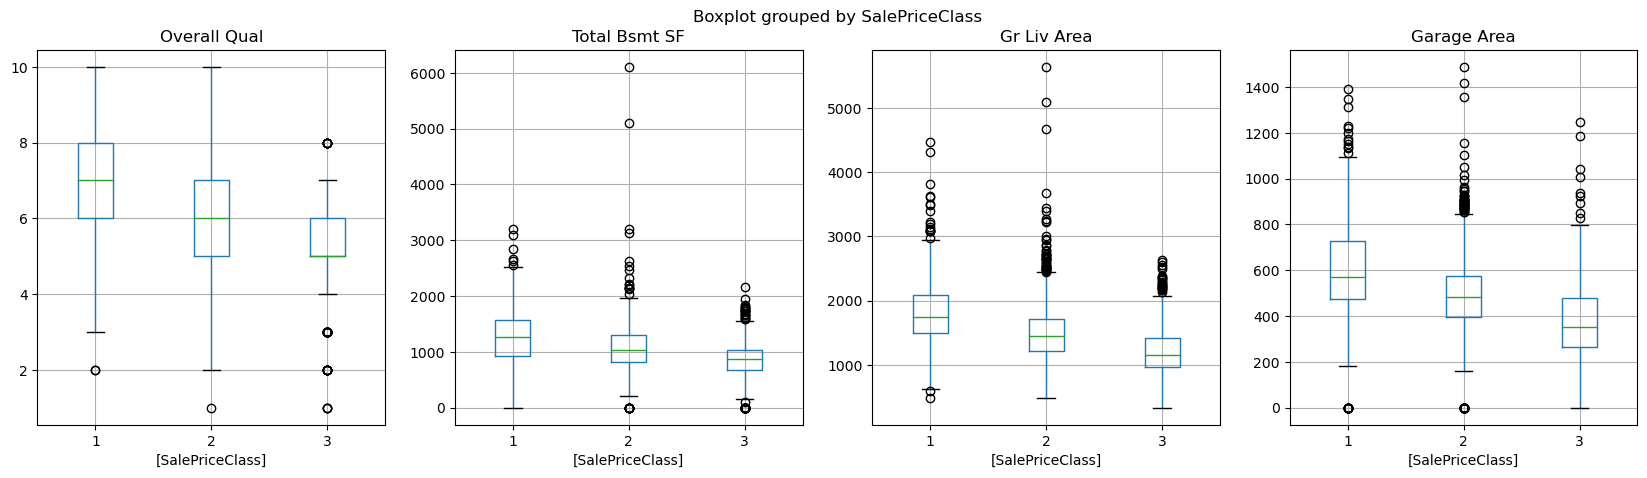

In [165]:
n = len(numerical_features_selected)

r, c = 1,4
fig, ax = plt.subplots(r, c, figsize=(20,5))

for i in range(n):
    feature = features_selected[i]
    ax = plt.subplot(r,c,i+1)
    ax.set_title(feature)
    data[['SalePriceClass',feature]].boxplot(by='SalePriceClass', ax=ax)

plt.show()

Finally, we combine the selected categorical and numerical features

In [166]:
features_selected = categorical_features_selected + numerical_features_selected
features_selected

['Garage_Finish_Encoded',
 'Bsmt_Qual_Encoded',
 'Total Bsmt SF',
 'Garage Area',
 'Age',
 'Total Flr SF']

## 6 Model Building

We will next build models based on the selected features.  We split the dataset into train/test set and then fit our model with the train dataset and evaluate the model using the test set.

In [167]:
### train_test_split

from sklearn.model_selection import train_test_split

X = data[features_selected]
y = data[["SalePriceClass"]]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)


We use the `model_selection` package form `sklearn` to split our dataset randomly into 75/25, i.e., we keep 25% of the dataset for model evaluation purpose.

To perform model fitting, we may also continue to utilise `sklearn`. For classification, the most commonly used models are [Naive Bayes](https://scikit-learn.org/stable/modules/naive_bayes.html), [Logistic Regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html#sklearn-linear-model-logisticregression), [Support Vector Machine](https://scikit-learn.org/stable/modules/svm.html),  [Decision Trees](https://scikit-learn.org/stable/modules/tree.html), [K-nearest-neighbours](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html). The approaches vary amongst the different models, for example, while Naive Bayes and Logistics Regression generates the probability of a data point belonging to each class, Support Vector Machine and Decision Trees classify each data point directly with attaching a probability associated with the class 

Here we would fit our data with `Naive Bayes` and `Logistic Regresion`. In particular for `Naive Bayes` we would choose the GaussianNB, which is applicable for numerical features. Other options are available where features are cateogorical.

In [168]:
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

model1 = GaussianNB().fit(X_train, y_train)

model2 = LogisticRegression().fit(X_train, y_train)

## 7 Model Evaluation

Finally we will evaluate our models using the metric *Accuracy* and *F1-score*.

In [169]:
## model 1 evaluation

from sklearn.metrics import f1_score, accuracy_score

# predict based on test set

y_pred = model1.predict(X_test)

# compare with ground truth

acc =  accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')

print("Model 1 Evaluation")
print("-----------------")
print(f"Accuracy: {acc:.3f}")
print(f"F1-score: {f1:.3f}")

Model 1 Evaluation
-----------------
Accuracy: 0.572
F1-score: 0.554


In [170]:
## model 1 evaluation

# predict based on test set

y_pred = model2.predict(X_test)

# compare with ground truth

acc =  accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')

print("Model 2 Evaluation")
print("-----------------")
print(f"Accuracy: {acc:.3f}")
print(f"F1-score: {f1:.3f}")

Model 2 Evaluation
-----------------
Accuracy: 0.553
F1-score: 0.539


Based on the evaluation metrics on the test set for the different models, we would select the model with the best evaluation score. In our case here, the evaluation scores of `Naive Bayes` are better than `Logistic Regression`. 

## 8 Conclusion

Our final model for the classification task, based on `Naive Bayes`, has an accuracy of 57.2% and F1-Score of 55.4% on the test set. Further, we note that since our dataset is quite balanced, accuracy score and F1-score is thus similar and either is a justifiable metric for measuring model performance

## 9 References
- Dataset: http://www.amstat.org/publications/jse/v19n3/decock/AmesHousing.xls 
- Data Dictionary: http://jse.amstat.org/v19n3/decock/DataDocumentation.txt